# FlyWire FAFB v783 — Exploratory Data Analysis
**Dataset:** https://codex.flywire.ai/?dataset=fafb

---
## Files used

| File | Rows | Used for |
|------|------|----------|
| `classification.csv` | 139,255 | Super-class, cell class, sub-class, flow, side, hemilineage |
| `neurons.csv` | 139,255 | NT type, confidence score, per-NT probability scores |
| `consolidated_cell_types.csv` | 138,327 | Primary cell type labels |
| `cell_stats.csv` | 139,246 | Cable length, surface area, volume |
| `connectivity_tags.csv` | 134,437 | Rich-club, reciprocal, feedforward, 3-cycle membership |
| `names.csv` | 139,255 | Neuropil group name per neuron |
| `labels.csv` | 160,045 | Community annotations by lab |
| `visual_neuron_types.csv` | 95,079 | Optic lobe family, subsystem, category |
| `column_assignment.csv` | 45,528 | Optic lobe column ID and hemisphere |
| `connections_princeton.csv` | 5,342,446 | Neuron-neuron connectivity, synapse counts, neuropil |

## Interactive vs static format decisions

| Plot | Format | Reason |
|------|--------|--------|
| Population overview | Static PDF | Simple distributions — no hover benefit |
| Cell hierarchy treemap | **Interactive HTML** | 3-level drill-down can't fit in one static figure |
| NT profile | Static PDF | Proportions communicate fine as PDF |
| NT confidence | Static PDF | Standard histograms |
| NT probability heatmap | **Interactive HTML** | Need hover to read exact per-cell values |
| Cell type coverage | Static PDF | Ranked bars |
| Morphology distributions | Static PDF | Overlaid histograms |
| Morphology scatter | **Interactive HTML** | Hover to identify neurons, zoom dense clusters |
| Network topology roles | Static PDF | Small category counts |
| Connectivity: degree & neuropils | Static PDF | Ranked lists and histograms |
| In vs out-degree scatter | **Interactive HTML** | 100K+ points: need hover + zoom |
| Pre × post NT heatmap | **Interactive HTML** | Hover for exact synapse counts per cell |
| Inhibitory deep-dive | Static PDF | Comparison bars and histograms |
| Community annotations | Static PDF | Ranked bars and timelines |
| Visual neuron types | Static PDF | Subsystem breakdown |

**All static plots are saved as PDF in `eda_outputs/`. All interactive plots are saved as self-contained HTML.**

## 0 — Setup

In [ ]:
!pip install plotly --quiet

In [ ]:
import warnings, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats

plt.rcParams.update({
    'pdf.fonttype': 42, 'font.sans-serif': ['Helvetica', 'Arial'],
    'font.size': 12, 'axes.titlesize': 13, 'axes.labelsize': 12,
    'axes.spines.top': False, 'axes.spines.right': False,
})
os.makedirs('eda_outputs', exist_ok=True)

PALETTE = {
    'optic': '#5C4B8A', 'central': '#3498DB', 'sensory': '#27AE60',
    'visual_projection': '#E67E22', 'descending': '#E74C3C',
    'ascending': '#9B59B6', 'motor': '#1ABC9C', 'endocrine': '#F39C12',
    'sensory_ascending': '#16A085', 'visual_centrifugal': '#D35400',
    'default': '#7F8C8D',
}
NT_COLORS = {
    'ACH': '#3498DB', 'GABA': '#E74C3C', 'GLUT': '#E67E22',
    'DA': '#9B59B6', 'SER': '#2ECC71', 'OCT': '#F39C12',
}
INHIBITORY = {'GABA', 'GLUT'}
EXCITATORY = {'ACH'}
MODULATORY = {'DA', 'SER', 'OCT'}

def src(text):
    """Add a source attribution footnote to the current figure."""
    plt.figtext(0.99, 0.01, f'Source: {text}', ha='right',
                fontsize=8, style='italic', color='gray')

print('Setup complete')

Setup complete



## 1 — Load All Files

The next cell picks the first available data source:

1. **Local repo** — `<repo_root>/data/fafb_v783/` (populated by running `python Flywire_FAFB/build_fafb_master.py` once from the repo root). This is the preferred path when running outside Colab.
2. **Google Drive** — `/content/drive/MyDrive/Barnard Drosophila/FAFB/Data_Files/` (falls back to mounting Drive on Colab if the local folder isn't present).

Filenames may be plain `.csv` or gzipped `.csv.gz` — pandas handles both transparently, so no code downstream needs to change.

In [ ]:
# Load FAFB v783 data from the first available source:
#   1. Local repo folder  <repo_root>/data/fafb_v783/   (preferred, populated
#      by Flywire_FAFB/build_fafb_master.py)
#   2. Google Drive       /content/drive/MyDrive/Barnard Drosophila/FAFB/Data_Files/
#
# Filenames may be plain `.csv` or gzipped `.csv.gz` — pandas handles both.
from pathlib import Path

IN_COLAB = 'google.colab' in str(globals().get('get_ipython', lambda: '')())

# --- Candidate data directories, checked in order ---
_candidate_dirs = []

# 1. Local repo path (works when the notebook lives inside the repo).
try:
    _nb_dir = Path(__file__).resolve().parent        # when run as .py
except NameError:
    _nb_dir = Path.cwd()                             # typical in Jupyter
for base in [_nb_dir, _nb_dir.parent, _nb_dir.parent.parent, Path.cwd(), Path.cwd().parent]:
    _candidate_dirs.append(base / 'data' / 'fafb_v783')
    _candidate_dirs.append(base / 'fafb_v783')

# 2. Google Drive fallback (Colab).
if IN_COLAB:
    try:
        from google.colab import drive  # noqa: F401
        if not os.path.ismount('/content/drive'):
            drive.mount('/content/drive')
    except Exception as _e:
        print(f'  (Could not mount Drive: {_e})')
    _candidate_dirs.append(Path('/content/drive/MyDrive/Barnard Drosophila/FAFB/Data_Files'))

DATA_DIR = None
for _d in _candidate_dirs:
    if _d.exists() and any(_d.glob('classification.csv*')):
        DATA_DIR = _d
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        'No FAFB data folder found. Either run '
        '`python Flywire_FAFB/build_fafb_master.py` from the repo root, '
        'or mount Google Drive with the expected folder layout.'
    )
print(f'Using DATA_DIR = {DATA_DIR}')


def _resolve(filename):
    """Return a Path to `filename` in DATA_DIR, accepting either .csv or .csv.gz."""
    p = DATA_DIR / filename
    if p.exists():
        return p
    if not filename.endswith('.gz'):
        pgz = DATA_DIR / f'{filename}.gz'
        if pgz.exists():
            return pgz
    return None


def load_file(filename, **kwargs):
    path = _resolve(filename)
    if path is None:
        print(f'  \u26a0  {filename} not found in {DATA_DIR} \u2014 dependent sections will be skipped')
        return pd.DataFrame()
    df = pd.read_csv(path, low_memory=False, **kwargs)
    print(f'  \u2713  {path.name:<45} {len(df):>9,} rows')
    return df


print(f'Loading all files from {DATA_DIR}...')
classification = load_file('classification.csv')
neurons        = load_file('neurons.csv')
cell_types     = load_file('consolidated_cell_types.csv')
cell_stats     = load_file('cell_stats.csv')
conn_tags      = load_file('connectivity_tags.csv')
names          = load_file('names.csv')
labels         = load_file('labels.csv')
visual_types   = load_file('visual_neuron_types.csv')
col_assign     = load_file('column_assignment.csv')

print('\nLoading connections file.')
conn_path = _resolve('connections_princeton.csv')
if conn_path is None:
    print(f'  \u26a0  connections_princeton.csv not found in {DATA_DIR}')
    connections = pd.DataFrame()
    HAS_CONN = False
else:
    try:
        connections = pd.read_csv(conn_path, low_memory=False)
        print(f'  \u2713  {conn_path.name:<45} {len(connections):>9,} rows')
        HAS_CONN = True
    except Exception as e:
        print(f'  \u26a0  Could not load connections: {e}')
        connections = pd.DataFrame()
        HAS_CONN = False

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading all files from Google Drive...
  ✓  classification.csv                              139,255 rows
  ✓  neurons.csv                                     139,255 rows
  ✓  consolidated_cell_types.csv                     138,327 rows
  ✓  cell_stats.csv                                  139,246 rows
  ✓  connectivity_tags.csv                           134,437 rows
  ✓  names.csv                                       139,255 rows
  ✓  labels.csv                                      160,045 rows
  ✓  visual_neuron_types.csv                          95,079 rows
  ✓  column_assignment.csv                            45,528 rows

Loading connections file.
  ✓  connections_princeton.csv                  5,342,446 rows


In [ ]:
# Build master table: join all neuron-level files on root_id
master = classification.copy()

for df, cols in [
    (neurons,    ['root_id','nt_type','nt_type_score','da_avg','ser_avg',
                  'gaba_avg','glut_avg','ach_avg','oct_avg','group']),
    (cell_types, ['root_id','primary_type']),
    (cell_stats, ['root_id','length_nm','area_nm','size_nm']),
    (names,      ['root_id','name']),
]:
    if not df.empty:
        keep = [c for c in cols if c in df.columns]
        master = master.merge(df[keep], on='root_id', how='left')

# Unit conversions
if 'length_nm' in master.columns:
    master['length_um']  = master['length_nm']  / 1_000
    master['area_um2']   = master['area_nm']    / 1_000_000
    master['volume_um3'] = master['size_nm']    / 1_000_000_000

# Parse connectivity tags into binary flags
if not conn_tags.empty:
    for tag, col in [('rich_club','rich_club'), ('reciprocal','reciprocal'),
                     ('feedforward','feedforward'), ('3_cycle','cycle_3')]:
        conn_tags[col] = conn_tags['connectivity_tag'].str.contains(tag, na=False)
    master = master.merge(
        conn_tags[['root_id','rich_club','reciprocal','feedforward','cycle_3']],
        on='root_id', how='left'
    )
    for col in ['rich_club','reciprocal','feedforward','cycle_3']:
        master[col] = master[col].fillna(False)

# Compute per-neuron degree from connections table
if HAS_CONN:
    pairs = connections.groupby(['pre_root_id','post_root_id'])['syn_count'].sum().reset_index()
    in_deg  = pairs.groupby('post_root_id')['pre_root_id'].nunique().rename('in_degree')
    out_deg = pairs.groupby('pre_root_id')['post_root_id'].nunique().rename('out_degree')
    in_str  = pairs.groupby('post_root_id')['syn_count'].sum().rename('in_strength')
    out_str = pairs.groupby('pre_root_id')['syn_count'].sum().rename('out_strength')
    degree_df = pd.concat([in_deg, out_deg, in_str, out_str], axis=1).fillna(0).astype(int)
    master = master.set_index('root_id').join(degree_df, how='left').reset_index()
    for col in ['in_degree','out_degree','in_strength','out_strength']:
        master[col] = master[col].fillna(0).astype(int)

N = len(master)
print(f'Master table: {N:,} neurons  ×  {master.shape[1]} columns')
print(f'Columns: {master.columns.tolist()}')

Master table: 139,255 neurons  ×  33 columns
Columns: ['root_id', 'flow', 'super_class', 'class', 'sub_class', 'hemilineage', 'side', 'nerve', 'nt_type', 'nt_type_score', 'da_avg', 'ser_avg', 'gaba_avg', 'glut_avg', 'ach_avg', 'oct_avg', 'group', 'primary_type', 'length_nm', 'area_nm', 'size_nm', 'name', 'length_um', 'area_um2', 'volume_um3', 'rich_club', 'reciprocal', 'feedforward', 'cycle_3', 'in_degree', 'out_degree', 'in_strength', 'out_strength']


## 2 — Population Overview
**Source: `classification.csv`**

In [ ]:
import matplotlib.font_manager as fm

plt.rcParams.update({
    'pdf.fonttype': 42,
    'font.sans-serif': ['DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif'],
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

In [ ]:
print('FlyWire FAFB v783 — Key Numbers')
print(f'  Proofread neurons:          {N:>10,}')
if HAS_CONN:
    print(f'  Connections (≥5 syn):       {len(connections):>10,}')
    print(f'  Total synapses (sum):       {connections["syn_count"].sum():>10,}')
    print(f'  Unique pre-neurons:         {connections["pre_root_id"].nunique():>10,}')
    print(f'  Unique post-neurons:        {connections["post_root_id"].nunique():>10,}')
    print(f'  Distinct neuropils:         {connections["neuropil"].nunique():>10,}')
print()
print('Annotation coverage:')
for col, label in [('super_class','super_class'), ('class','cell class'),
                    ('nt_type','NT type'), ('primary_type','primary cell type'),
                    ('side','side'), ('hemilineage','hemilineage')]:
    if col in master.columns:
        pct = 100 * (master[col].notna() & (master[col].astype(str).str.strip() != '')).mean()
        bar = '█'*int(pct/5) + '░'*(20-int(pct/5))
        print(f'  {label:<22} {bar}  {pct:5.1f}%')

FlyWire FAFB v783 — Key Numbers
  Proofread neurons:             139,255
  Connections (≥5 syn):        5,342,446
  Total synapses (sum):       50,666,648
  Unique pre-neurons:            137,518
  Unique post-neurons:           130,183
  Distinct neuropils:                 79

Annotation coverage:
  super_class            ████████████████████  100.0%
  cell class             ███████████████░░░░░   77.3%
  NT type                █████████████████░░░   85.9%
  primary cell type      ███████████████████░   99.3%
  side                   ███████████████████░  100.0%
  hemilineage            █████░░░░░░░░░░░░░░░   27.0%


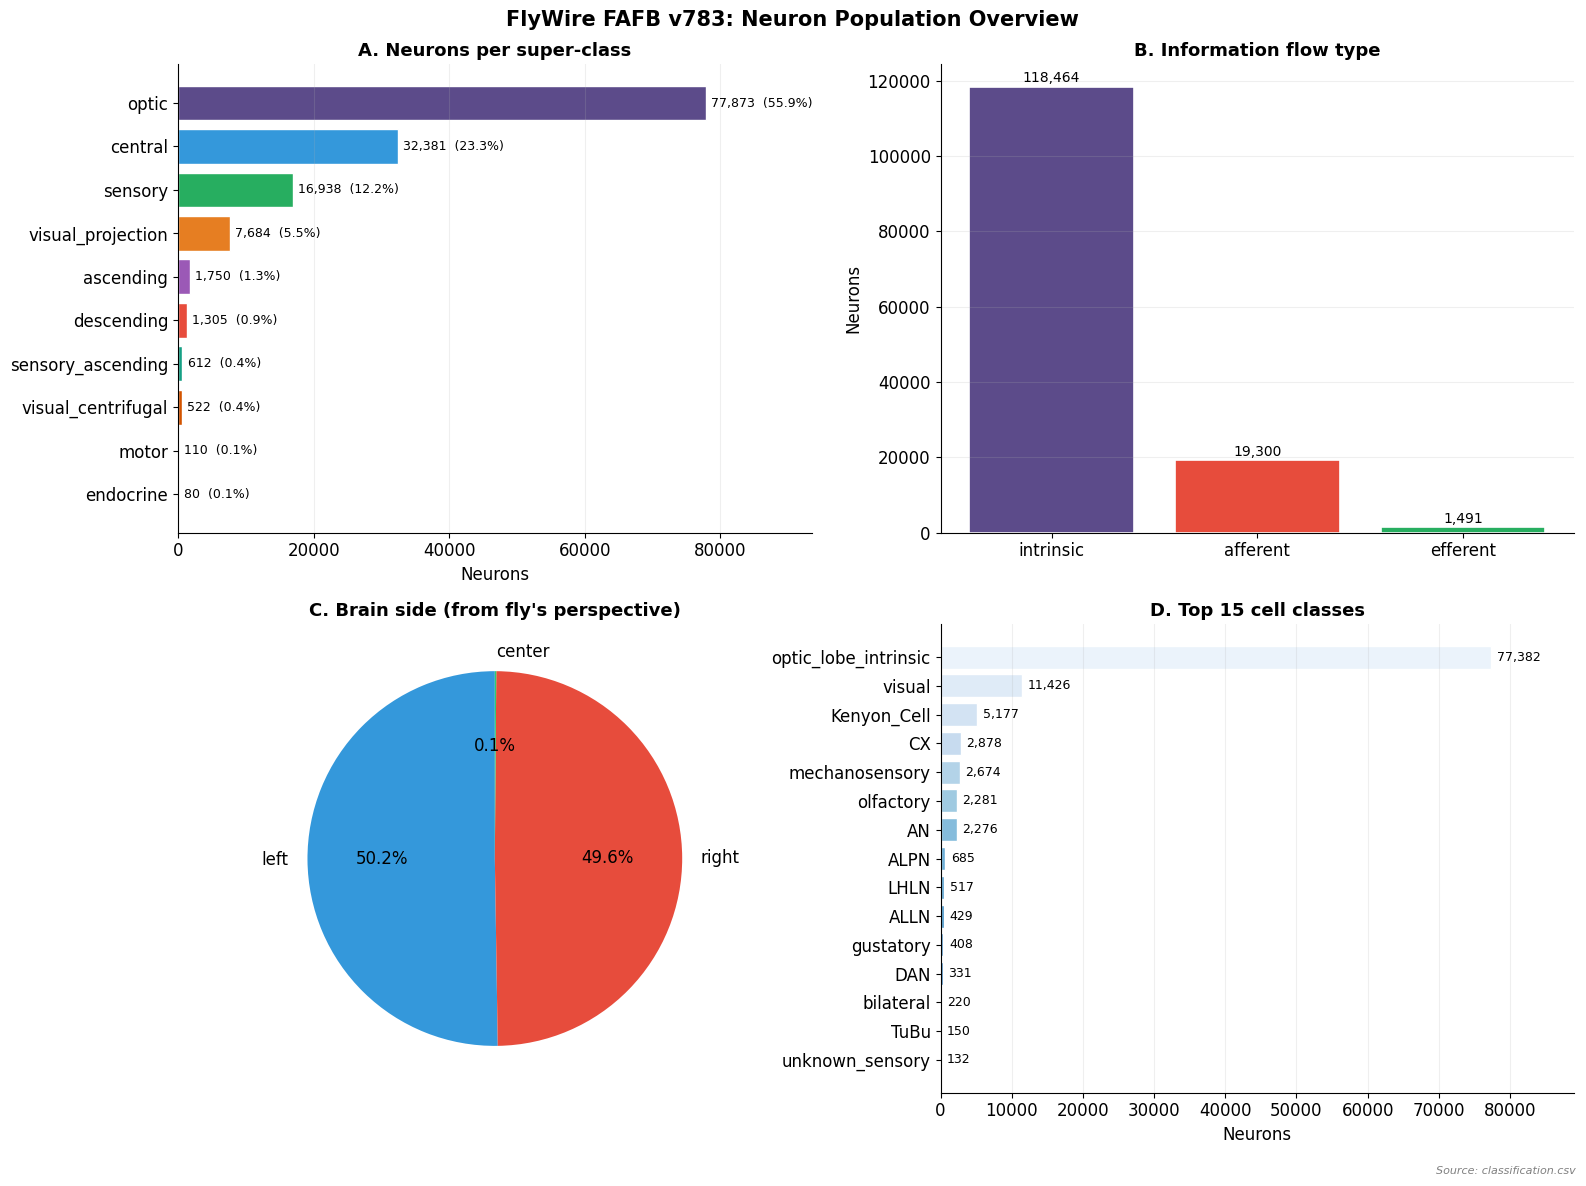

In [ ]:
# STATIC: population overview — 4 panels
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# A: Super-class
ax = axes[0, 0]
sc = master['super_class'].value_counts().dropna()
colors_sc = [PALETTE.get(c, PALETTE['default']) for c in sc.index]
bars = ax.barh(sc.index[::-1], sc.values[::-1], color=colors_sc[::-1], edgecolor='white')
for bar, v in zip(bars, sc.values[::-1]):
    ax.text(bar.get_width()+sc.max()*0.01, bar.get_y()+bar.get_height()/2,
            f'{v:,}  ({100*v/N:.1f}%)', va='center', fontsize=9)
ax.set_xlabel('Neurons'); ax.set_title('A. Neurons per super-class', fontweight='bold')
ax.set_xlim(0, sc.max()*1.20); ax.grid(True, axis='x', alpha=0.2)

# B: Flow type
ax = axes[0, 1]
fl = master['flow'].value_counts().dropna()
colors_fl = ['#5C4B8A','#E74C3C','#27AE60'][:len(fl)]
bars = ax.bar(fl.index, fl.values, color=colors_fl, edgecolor='white', linewidth=1.2)
for bar, v in zip(bars, fl.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+fl.max()*0.01,
            f'{v:,}', ha='center', fontsize=10)
ax.set_ylabel('Neurons'); ax.set_title('B. Information flow type', fontweight='bold')
ax.grid(True, axis='y', alpha=0.2)

# C: Brain side
ax = axes[1, 0]
sd = master['side'].value_counts().dropna()
ax.pie(sd.values, labels=sd.index, autopct='%1.1f%%', startangle=90,
       colors=['#3498DB','#E74C3C','#2ECC71','#BDC3C7'][:len(sd)])
ax.set_title("C. Brain side (from fly's perspective)", fontweight='bold')

# D: Top 15 cell classes
ax = axes[1, 1]
cc = master['class'].value_counts().dropna().head(15)
bars = ax.barh(cc.index[::-1], cc.values[::-1],
               color=sns.color_palette('Blues_r', len(cc)), edgecolor='white')
for bar, v in zip(bars, cc.values[::-1]):
    ax.text(bar.get_width()+cc.max()*0.01, bar.get_y()+bar.get_height()/2,
            f'{v:,}', va='center', fontsize=9)
ax.set_xlabel('Neurons'); ax.set_title('D. Top 15 cell classes', fontweight='bold')
ax.set_xlim(0, cc.max()*1.15); ax.grid(True, axis='x', alpha=0.2)

plt.suptitle('FlyWire FAFB v783: Neuron Population Overview', fontsize=15, fontweight='bold')
src('classification.csv')
plt.tight_layout(rect=[0,0.02,1,1])
plt.savefig('eda_outputs/01_population_overview.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Neuron Population Overview

This figure gives a first look at the 139,255 neurons in the FlyWire Female Adult Fly Brain (FAFB) connectome — essentially a complete wiring diagram of an adult *Drosophila* brain.

### What the four panels show

**A. Super-class distribution**  
Neurons are grouped into broad biological categories. Over half (55.9%, n=77,873) belong to the **optic** super-class — these are neurons dedicated to processing visual information in the fly's large compound eyes. The next largest group is **central** neurons (23.3%), which handle higher-order processing across brain regions. **Sensory** neurons (12.2%) relay signals from the outside world, while smaller populations handle specific roles: visual projection (5.5%), ascending/descending signals between the brain and body, motor control, and hormonal (endocrine) output.

**B. Information flow type**  
Each neuron is classified by the direction information flows through it. The vast majority are **intrinsic** (118,464) — they process information entirely within the brain. **Afferent** neurons (19,300) bring signals *into* the brain from the senses, while **efferent** neurons (1,491) carry commands *out* to muscles and other parts of the body. This 85/14/1 split reflects that most of the brain's work is internal computation rather than direct input or output.

**C. Brain side**  
The brain is nearly perfectly symmetric: 50.2% of neurons sit on the left side, 49.6% on the right, with just 0.1% at the midline (center). This bilateral symmetry is a hallmark of fly brain organisation and means analyses done on one hemisphere should generalise well to the other.

**D. Top 15 cell classes**  
This panel drills one level deeper than super-class. The dominant group is **optic lobe intrinsic** neurons (77,382) — consistent with Panel A. Beyond the visual system, notable populations include **Kenyon Cells** (5,177), which are the memory-storing neurons of the mushroom body, **CX** neurons (2,878) in the central complex which control navigation and action selection, and **olfactory** neurons (2,281) which process smell. Many of these smaller populations are the ones most relevant to circuit-level studies of behaviour.

### Key takeaways for analysis
- The dataset is **dominated by the optic lobe** — any whole-brain statistic (average degree, NT type fraction, etc.) will be heavily influenced by visual neurons. It is worth filtering by super-class when asking questions about non-visual circuits.
- The near-perfect **left-right symmetry** is a useful sanity check: any metric that differs dramatically between hemispheres warrants investigation.
- **Kenyon Cells, CX, and olfactory neurons** are small in number but biologically well-studied — good starting points for targeted follow-up analyses.

In [ ]:
# INTERACTIVE: cell hierarchy treema
# Source: classification.csv
# Interactive because 3-level drill-down (super_class → class → sub_class)
# cannot be shown in a single readable static figure.

tree_df = (
    master
    .dropna(subset=['super_class','class'])
    [master['class'].astype(str).str.strip() != '']
    .groupby(['super_class','class']).size().reset_index(name='count')
)
fig = px.treemap(
    tree_df, path=['super_class','class'], values='count',
    color='count', color_continuous_scale='Purples',
    title='FlyWire FAFB v783: Cell hierarchy — click any super-class to drill into cell classes',
    hover_data={'count': ':,d'}
)
fig.update_traces(textinfo='label+value')
fig.update_layout(height=540, margin=dict(t=60,l=10,r=10,b=30), coloraxis_showscale=False)
fig.add_annotation(text='Source: classification.csv', xref='paper', yref='paper',
                   x=1, y=-0.04, showarrow=False, font=dict(size=9, color='gray'), xanchor='right')
fig.write_html('eda_outputs/02_cell_hierarchy_treemap.html', include_plotlyjs='cdn')
fig.show()
print('Saved: eda_outputs/02_cell_hierarchy_treemap.html')

Saved: eda_outputs/02_cell_hierarchy_treemap.html


## Cell Hierarchy Treemap

This interactive treemap shows the same 139,255 neurons organised into a two-level hierarchy: **super-class** (the large labelled rectangles) breaking down into **cell classes** (the smaller rectangles inside each). The area of each rectangle is proportional to the number of neurons in that group — bigger box means more neurons.

### How to read it

Each large outlined region is a super-class. Inside it, each smaller box is a cell class belonging to that super-class. You can click any super-class region to zoom in and see its cell classes more clearly, then click the top bar to zoom back out.

### What stands out

**The optic super-class dominates completely.** Its single cell class — `optic_lobe_intrinsic` (77,382 neurons) — takes up the entire left half of the figure. This is a direct visual reminder of Panel A from the previous figure: more than half the fly brain, by neuron count, is dedicated to visual processing.

**The sensory super-class** (top right) breaks into several distinct classes: `visual` (11,426), `mechanosensory` (2,674), and `olfactory` (2,281), among smaller ones. This reflects the fly's major sensory modalities — light, touch/vibration, and smell.

**The central super-class** (bottom right) contains the most biologically diverse cell classes: `Kenyon_Cell` (5,177) for memory, `CX` (2,878) for navigation and action selection, `DAN` (331) dopaminergic neurons that signal reward, `MBON` output neurons from the mushroom body, and several others involved in higher-order computation.

**The ascending super-class** is small but notable — `AN` neurons (1,750 + 526) carry signals up from the ventral nerve cord (the fly's spinal cord equivalent) into the brain.

### Key takeaway for analysis

The extreme size imbalance between optic and everything else means that **any analysis run on the whole brain without filtering will be dominated by optic lobe biology**. If your question is about central brain circuits — memory, olfaction, navigation — it is worth subsetting to `super_class != 'optic'` early in the analysis pipeline.

## 3 — Neurotransmitter Profile
**Source: `neurons.csv`, `classification.csv`**

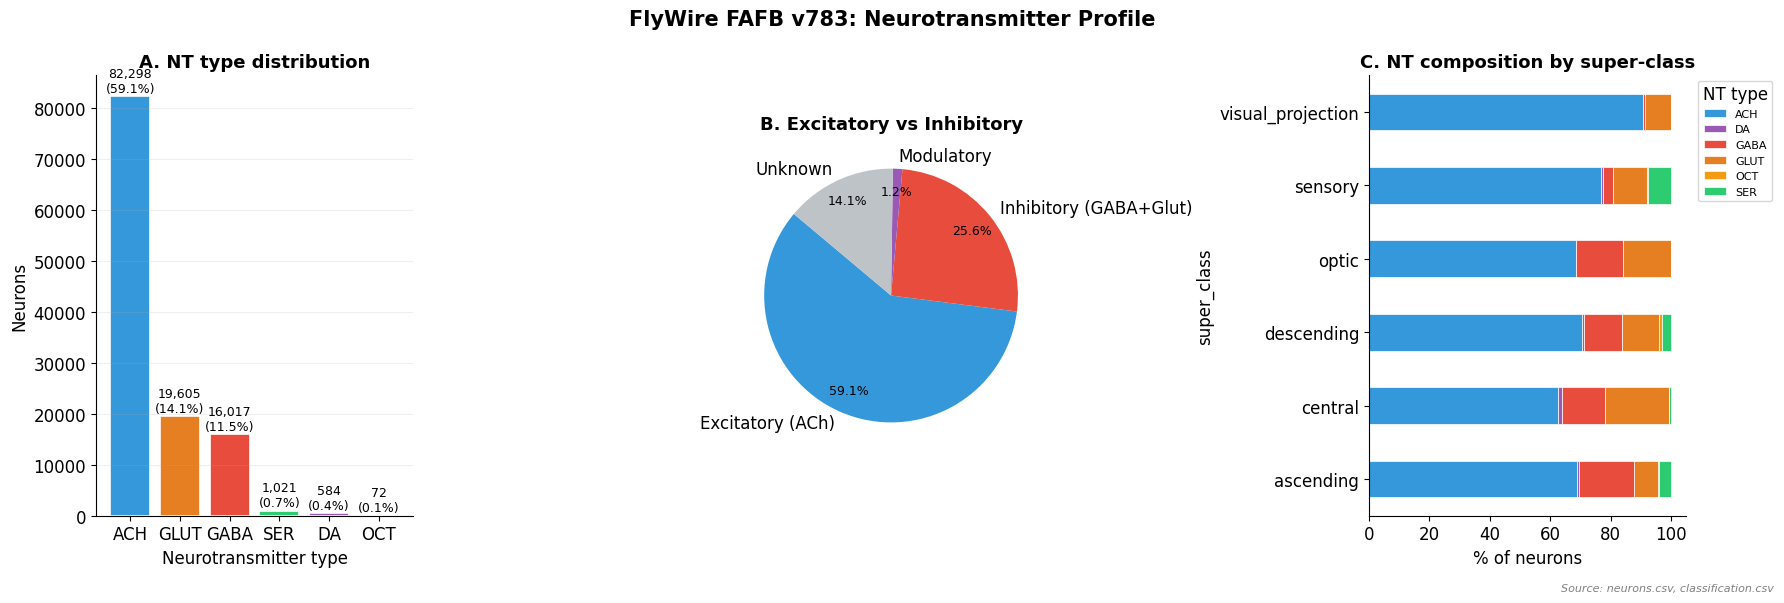

In [ ]:
# STATIC: NT overview — 3 panels
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# A: NT type bar chart
ax = axes[0]
nt_c = master['nt_type'].value_counts().dropna()
nt_c = nt_c[nt_c.index.isin(NT_COLORS)]
bar_cols = [NT_COLORS[k] for k in nt_c.index]
bars = ax.bar(nt_c.index, nt_c.values, color=bar_cols, edgecolor='white', linewidth=1.2)
for bar, v in zip(bars, nt_c.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+nt_c.max()*0.01,
            f'{v:,}\n({100*v/N:.1f}%)', ha='center', fontsize=9)
ax.set_ylabel('Neurons'); ax.set_xlabel('Neurotransmitter type')
ax.set_title('A. NT type distribution', fontweight='bold')
ax.grid(True, axis='y', alpha=0.2)

# B: Broad category pie
ax = axes[1]
nt_u = master['nt_type'].fillna('')
broad = {'Excitatory (ACh)':       nt_u.isin(EXCITATORY).sum(),
         'Inhibitory (GABA+Glut)': nt_u.isin(INHIBITORY).sum(),
         'Modulatory':              nt_u.isin(MODULATORY).sum(),
         'Unknown':                 (~nt_u.isin(EXCITATORY|INHIBITORY|MODULATORY)).sum()}
broad = {k:v for k,v in broad.items() if v>0}
_, _, autos = ax.pie(list(broad.values()), labels=list(broad.keys()),
                     colors=['#3498DB','#E74C3C','#9B59B6','#BDC3C7'][:len(broad)],
                     autopct='%1.1f%%', startangle=140, pctdistance=0.82)
for t in autos: t.set_fontsize(9)
ax.set_title('B. Excitatory vs Inhibitory', fontweight='bold')

# C: NT by super_class (stacked %)
ax = axes[2]
top_sc = master['super_class'].value_counts().head(6).index
cross = (master[master['super_class'].isin(top_sc) & master['nt_type'].isin(NT_COLORS)]
         .groupby(['super_class','nt_type']).size().unstack(fill_value=0))
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
cross_pct.plot(kind='barh', stacked=True, ax=ax,
               color=[NT_COLORS.get(c,'#95A5A6') for c in cross_pct.columns],
               edgecolor='white', linewidth=0.5)
ax.set_xlabel('% of neurons')
ax.set_title('C. NT composition by super-class', fontweight='bold')
ax.legend(title='NT type', bbox_to_anchor=(1.02,1), fontsize=8)

plt.suptitle('FlyWire FAFB v783: Neurotransmitter Profile', fontsize=15, fontweight='bold')
src('neurons.csv, classification.csv')
plt.tight_layout(rect=[0,0.02,1,1])
plt.savefig('eda_outputs/03_nt_profile.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Neurotransmitter Profile

This figure shows what chemical signals the 139,255 neurons use to communicate. Every synapse in the brain uses a neurotransmitter — a molecule that either excites the receiving neuron (makes it more likely to fire) or inhibits it (makes it less likely to fire). FlyWire includes a machine-learning prediction of the dominant neurotransmitter for each neuron, based on the appearance of its synaptic terminals in the electron microscopy images.

### What the three panels show

**A. NT type distribution**  
Acetylcholine (ACH) is by far the most common neurotransmitter, used by 82,298 neurons (59.1%). Glutamate (GLUT, 19,605) and GABA (16,017) are the next most common. The modulatory types — serotonin (SER), dopamine (DA), and octopamine (OCT) — are rare but biologically significant: they regulate brain-wide states like arousal, reward, and stress rather than carrying point-to-point signals.

**B. Excitatory vs Inhibitory**  
Grouping by function: 59.1% of neurons are **excitatory** (ACH), 25.6% are **inhibitory** (GABA + GLUT combined), 1.2% are **modulatory**, and 14.1% have no confident prediction. The roughly 2:1 excitatory-to-inhibitory ratio is consistent with what is seen in other nervous systems and reflects the general principle that most neurons drive activity forward, with a substantial inhibitory population providing control and precision.

**C. NT composition by super-class**  
This panel reveals that the NT landscape is not uniform across the brain. A few patterns stand out:
- **Visual projection and sensory** neurons are almost entirely ACH — the fly's sensory periphery predominantly uses excitatory signalling
- **Optic** neurons show a much more mixed profile, with a substantial GLUT (orange) fraction alongside ACH — consistent with the known diversity of excitatory neuron types in the visual system
- **Central** neurons have the most balanced mix, with visible GABA (red) and GLUT fractions alongside ACH, reflecting the complex push-pull dynamics needed for higher-order computation
- **Ascending and descending** neurons are predominantly ACH with small inhibitory fractions

### Key takeaways for analysis
- NT type is a useful filter for any functional question: selecting `nt_type == 'GABA'` or `nt_type == 'GLUT'` gives a clean inhibitory population to work with
- The 14.1% unknown fraction means NT-based analyses will have incomplete coverage — worth noting as a caveat
- The optic lobe's glutamate fraction is unusually high relative to other super-classes, which is worth keeping in mind when comparing NT statistics across brain regions

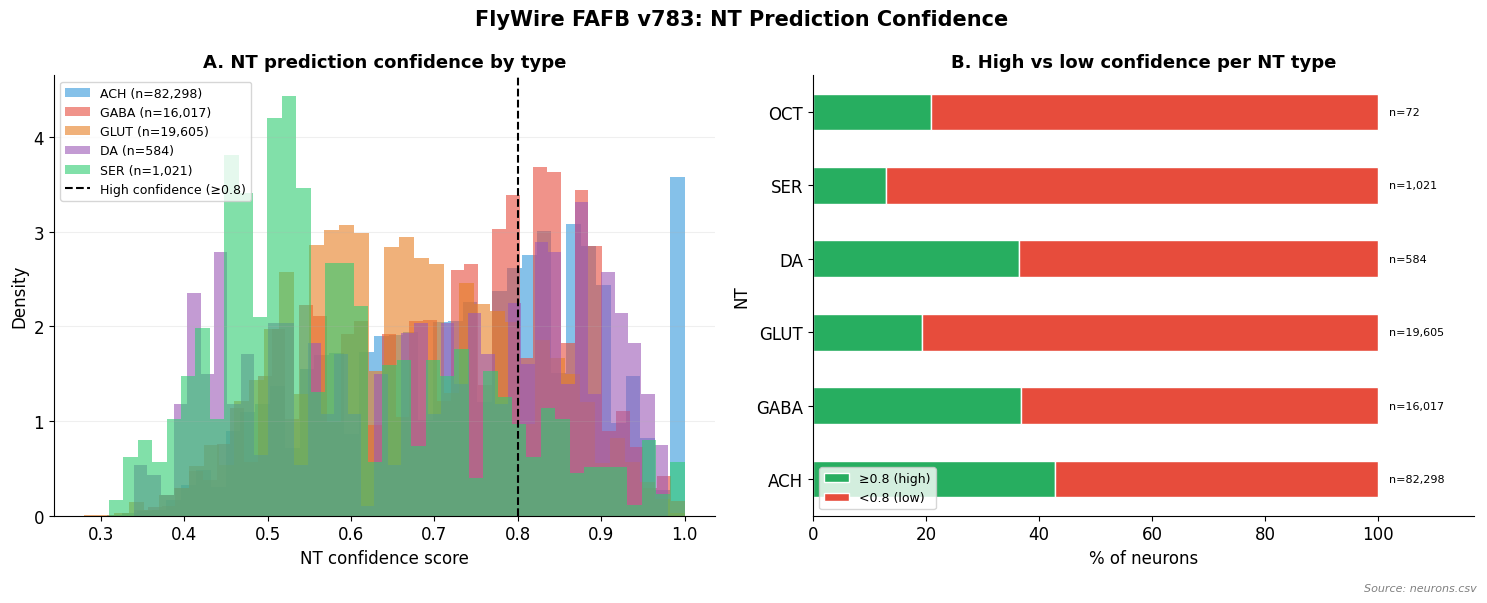

In [ ]:
# STATIC: NT confidence scores — 2 panels
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# A: Score distribution by NT type
ax = axes[0]
for nt in ['ACH','GABA','GLUT','DA','SER']:
    sub = master[master['nt_type']==nt]['nt_type_score'].dropna()
    if len(sub) > 10:
        ax.hist(sub, bins=40, alpha=0.6, color=NT_COLORS[nt],
                label=f'{nt} (n={len(sub):,})', density=True)
ax.axvline(0.8, color='black', linestyle='--', linewidth=1.5,
           label='High confidence (≥0.8)')
ax.set_xlabel('NT confidence score'); ax.set_ylabel('Density')
ax.set_title('A. NT prediction confidence by type', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.2)

# B: High vs low confidence per NT type
ax = axes[1]
conf_rows = []
for nt in ['ACH','GABA','GLUT','DA','SER','OCT']:
    sub = master[master['nt_type']==nt]
    if len(sub)==0: continue
    conf_rows.append({'NT': nt,
                      '≥0.8 (high)': (sub['nt_type_score']>=0.8).sum(),
                      '<0.8 (low)':  (sub['nt_type_score']<0.8).sum()})
conf_df = pd.DataFrame(conf_rows).set_index('NT')
conf_pct = conf_df.div(conf_df.sum(axis=1), axis=0) * 100
conf_pct.plot(kind='barh', stacked=True, ax=ax,
              color=['#27AE60','#E74C3C'], edgecolor='white')
ax.set_xlabel('% of neurons')
ax.set_title('B. High vs low confidence per NT type', fontweight='bold')
ax.legend(fontsize=9)
for i, (nt, row) in enumerate(conf_df.iterrows()):
    ax.text(102, i, f'n={row.sum():,}', va='center', fontsize=8)
ax.set_xlim(0, 117)

plt.suptitle('FlyWire FAFB v783: NT Prediction Confidence', fontsize=15, fontweight='bold')
src('neurons.csv')
plt.tight_layout(rect=[0,0.02,1,1])
plt.savefig('eda_outputs/04_nt_confidence.pdf', dpi=150, bbox_inches='tight')
plt.show()

## NT Prediction Confidence

The neurotransmitter labels in this dataset come from a machine-learning model, not direct measurement. This figure shows how confident those predictions are — which matters a lot for deciding how much to trust the NT labels in downstream analyses.

### What the two panels show

**A. Confidence score distributions by NT type**  
Each neuron gets a confidence score between 0 and 1 for its predicted NT type. The dashed line at 0.8 marks the commonly used threshold for "high confidence." A few things stand out:

- **ACH** (blue) has a strong spike near 1.0 — many ACH-predicted neurons have very high confidence. It also has a secondary mass around 0.5–0.7, meaning a substantial fraction are less certain
- **GABA** (red/pink) peaks just above 0.8, suggesting reasonably confident predictions overall
- **GLUT** (orange) is spread more broadly between 0.5 and 0.8 — flatter and less peaked, indicating more uncertainty on average
- **SER** (green) and **DA** (purple) are widely spread and noisy — their predictions are the least reliable, which makes sense given how rare these neuron types are (the model has fewer examples to learn from)

**B. High vs low confidence per NT type**  
This panel makes the reliability gap concrete. Only the green portion (≥0.8) should be considered high-confidence.

- **ACH**: ~40% high confidence — the largest NT type but only about 4 in 10 predictions clear the threshold
- **GABA**: ~35% high confidence
- **DA**: ~35% high confidence
- **GLUT**: ~20% high confidence — most glutamate predictions are below the threshold
- **SER**: ~15% high confidence
- **OCT**: ~20% high confidence — though with only n=72 neurons the sample is very small

### Key takeaways for analysis
- **Most NT predictions are low confidence.** Across all types, the majority of neurons fall below 0.8. This does not mean the labels are wrong — the assigned NT is still the *most likely* type — but it does mean you should be cautious about hard filtering by NT type without also filtering by confidence score
- A practical approach: use `nt_type_score >= 0.8` as an additional filter when NT identity is critical to your question, and report how many neurons this retains
- **Rare NT types (SER, OCT, DA) are the least reliable** and should be interpreted with extra caution given both low confidence and small sample sizes

In [ ]:
# INTERACTIVE: NT probability score heatmap
# Source: neurons.csv
# Interactive: hover to read exact median probability for each NT × predicted type cell.

score_cols = [c for c in ['gaba_avg','ach_avg','glut_avg','da_avg','ser_avg','oct_avg']
              if c in master.columns]
pivot = (master[master['nt_type'].isin(NT_COLORS)]
         .groupby('nt_type')[score_cols].median().round(3))
pivot.columns = [c.replace('_avg','').upper() for c in pivot.columns]
pivot.index.name = 'Predicted NT'

fig = px.imshow(
    pivot, color_continuous_scale='Blues', zmin=0, zmax=1,
    title='FlyWire FAFB v783: Median NT probability score per predicted NT type<br>'
          '<sub>Each cell = median probability across all neurons of that type. '
          'A well-calibrated predictor shows high values on the diagonal. '
          'Hover for exact values. Source: neurons.csv</sub>',
    labels=dict(x='NT score column', y='Predicted NT type', color='Median prob.'),
    text_auto='.3f', aspect='auto'
)
fig.update_layout(height=400, margin=dict(t=120,b=60,l=120,r=60))
fig.write_html('eda_outputs/05_nt_probability_heatmap.html', include_plotlyjs='cdn')
fig.show()
print('Saved: eda_outputs/05_nt_probability_heatmap.html')

Saved: eda_outputs/05_nt_probability_heatmap.html


## NT Probability Score Heatmap

### What this plot is
This is a **calibration check** for the machine-learning model that predicts neurotransmitter types. Rather than just showing which NT type each neuron was assigned, it shows the raw probability scores the model produced for *every* NT type simultaneously — and whether the model's confidence actually lines up with its assignments.

### How to read it
- **Rows** = the NT type the model predicted for each neuron (e.g. the ACH row = all neurons predicted to be ACH)
- **Columns** = the six NT probability score columns in `neurons.csv` (e.g. `ach_avg`, `gaba_avg`, etc.)
- **Each cell** = the median probability score that neurons in that row received for that column's NT type
- **Darker blue** = higher median probability

A well-calibrated model should show **high values along the diagonal** — meaning neurons predicted as ACH should have a high ACH score, neurons predicted as GABA should have a high GABA score, and so on. Off-diagonal values represent how much the model considered alternative NT types.

### When you hover over a cell
The hover tooltip shows the exact median probability score for that row/column combination. For example, hovering over the ACH row × ACH column cell shows `0.760` — meaning the median neuron predicted as ACH had a 76% probability of being ACH according to the model.

### What the heatmap tells us

**The diagonal is dominant but imperfect:**
- ACH → ACH: 0.760 ✓
- GABA → GABA: 0.740 ✓
- DA → DA: 0.720 ✓
- GLUT → GLUT: 0.660 ✓
- OCT → OCT: 0.660 ✓
- SER → SER: 0.550 — the weakest diagonal value

All predicted types score highest on their own column, which confirms the model is working correctly. However, none reach 1.0, meaning there is always some residual probability assigned to other NT types.

**The off-diagonal values reveal confusion between types:**
- **GLUT** neurons have a notable GABA score of 0.190 — the model is less certain distinguishing glutamate from GABA, which are both inhibitory. This is consistent with the lower confidence scores seen for GLUT in the previous figure
- **SER** neurons have a surprisingly high ACH score of 0.210 — meaning for many serotonin-predicted neurons, acetylcholine was a close second. This is a flag to treat SER predictions with extra caution
- **GABA** neurons have a GLUT score of 0.120, again reflecting that the two inhibitory types can look similar to the model

### Key takeaway
This plot is the most direct window into **where the NT predictions might be wrong**. The safest NT types to use in analysis are ACH, GABA, and DA — their diagonal scores are highest and off-diagonal confusion is relatively low. GLUT, SER, and OCT predictions carry more uncertainty and should be filtered by confidence score (≥0.8) before being used in any functional interpretation.

## 4 — Cell Type Coverage
**Source: `consolidated_cell_types.csv`, `classification.csv`**

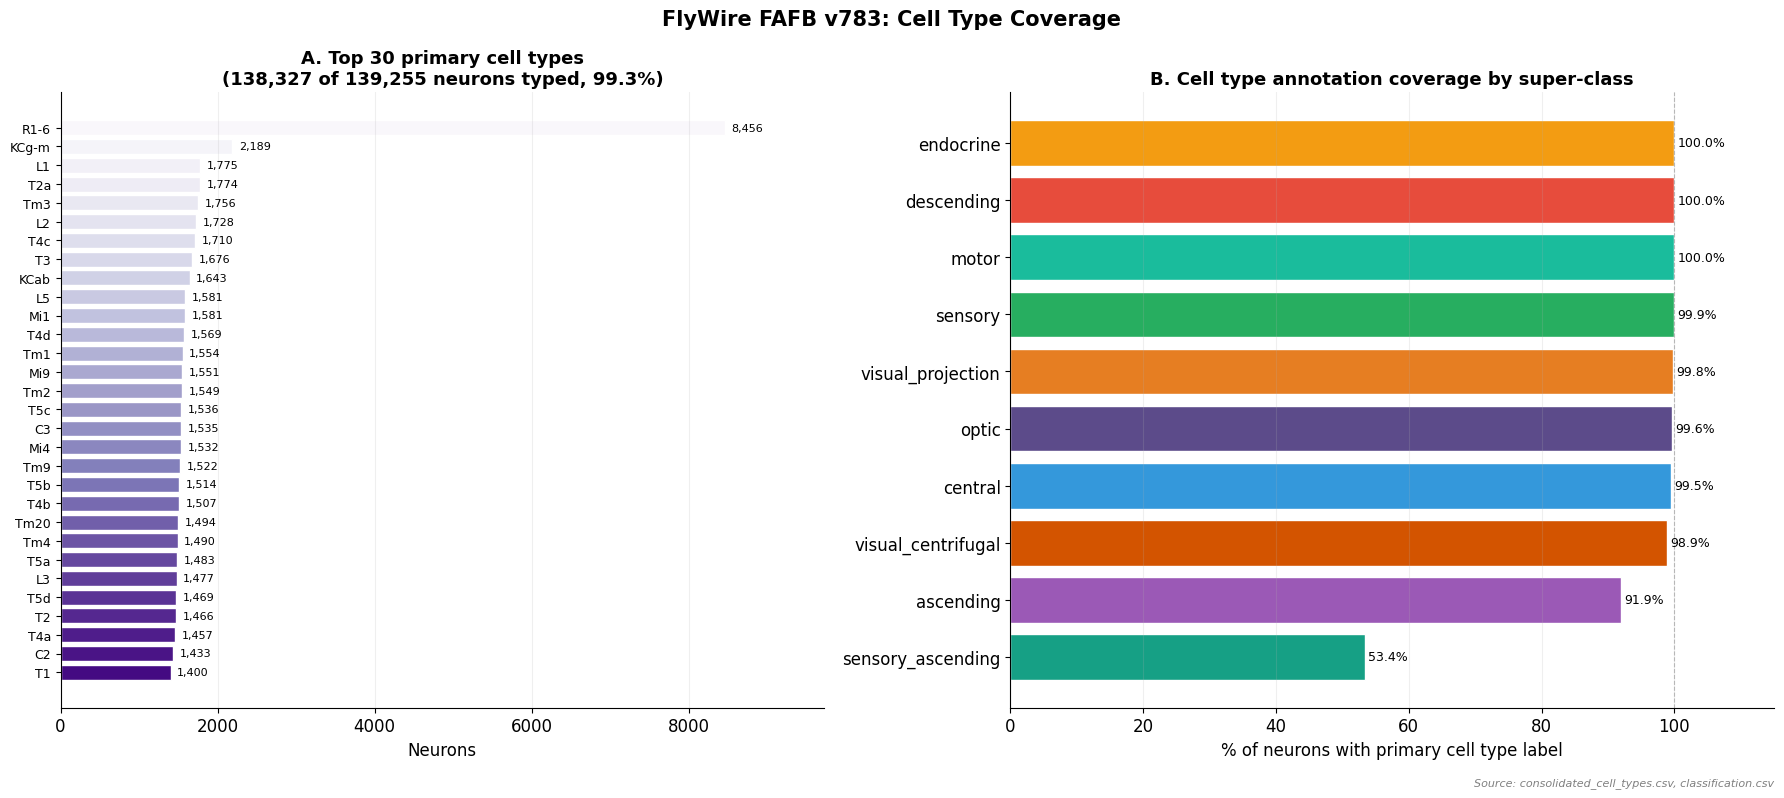

In [ ]:
# STATIC: top 30 cell types + coverage by super-class
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# A: Top 30 primary cell types
ax = axes[0]
if 'primary_type' in master.columns:
    ct = master['primary_type'].value_counts().dropna().head(30)
    bars = ax.barh(ct.index[::-1], ct.values[::-1],
                   color=sns.color_palette('Purples_r', len(ct)), edgecolor='white')
    for bar, v in zip(bars, ct.values[::-1]):
        ax.text(bar.get_width()+ct.max()*0.01, bar.get_y()+bar.get_height()/2,
                f'{v:,}', va='center', fontsize=8)
    n_typed = master['primary_type'].notna().sum()
    ax.set_xlabel('Neurons')
    ax.set_title(f'A. Top 30 primary cell types\n({n_typed:,} of {N:,} neurons typed, '
                 f'{100*n_typed/N:.1f}%)', fontweight='bold')
    ax.set_xlim(0, ct.max()*1.15)
    ax.grid(True, axis='x', alpha=0.2); ax.tick_params(axis='y', labelsize=9)

# B: Annotation coverage % per super-class
ax = axes[1]
if 'primary_type' in master.columns:
    cov = (master.groupby('super_class')['primary_type']
           .apply(lambda x: 100*x.notna().mean())
           .sort_values(ascending=False))
    bar_cols = [PALETTE.get(sc, PALETTE['default']) for sc in cov.index]
    ax.barh(cov.index[::-1], cov.values[::-1], color=bar_cols[::-1], edgecolor='white')
    ax.axvline(100, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    for i, (sc, v) in enumerate(zip(cov.index[::-1], cov.values[::-1])):
        ax.text(v+0.5, i, f'{v:.1f}%', va='center', fontsize=9)
    ax.set_xlabel('% of neurons with primary cell type label')
    ax.set_title('B. Cell type annotation coverage by super-class', fontweight='bold')
    ax.set_xlim(0, 115); ax.grid(True, axis='x', alpha=0.2)

plt.suptitle('FlyWire FAFB v783: Cell Type Coverage', fontsize=15, fontweight='bold')
src('consolidated_cell_types.csv, classification.csv')
plt.tight_layout(rect=[0,0.02,1,1])
plt.savefig('eda_outputs/06_cell_type_coverage.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Cell Type Coverage

### What this plot is
This figure shows how well the neurons in the dataset have been assigned specific **cell type labels** — the finest-grained biological classification, identifying exactly which type of neuron each cell is (e.g. "T4c" or "Mi1" rather than just "optic lobe intrinsic"). Cell type labels come from expert annotation and published literature, compiled in `consolidated_cell_types.csv`.

### Key headline number
**99.3% of neurons (138,327 of 139,255) have been assigned a primary cell type.** This is exceptionally high coverage and means cell type is a reliable column to use for filtering and grouping throughout the analysis.

### Panel A — Top 30 primary cell types
The most numerous cell type is **R1-6** (8,456 neurons) — these are the photoreceptor axons from the fly's compound eye, one of the most studied neuron types in all of neuroscience. The next tier (~1,400–2,200 neurons each) is dominated by optic lobe cell types with short codes:
- **L1, L2, L3, L5** — lamina monopolar neurons, the first visual processing layer
- **T2a, T3, T4a/b/c/d, T5a/b/c/d** — T-neurons that detect moving edges, central to motion vision
- **Tm1, Tm2, Tm3, Tm4, Tm9, Tm20** — transmedullary neurons connecting visual processing layers
- **Mi1, Mi4, Mi9** — medullary intrinsic neurons involved in ON-pathway visual processing
- **KCg-m, KCab** — Kenyon Cells from the mushroom body (memory)
- **C2, C3** — centrifugal neurons feeding back from the brain into the optic lobe

The relatively uniform bar lengths in positions 2–30 (all roughly 1,400–2,200) reflect the bilateral symmetry of the fly brain — most cell types appear in matched pairs across the left and right hemispheres and across repeated visual columns.

### Panel B — Annotation coverage by super-class
Nearly every super-class has near-complete cell type labelling:
- **Endocrine, descending, motor**: 100% — small, well-studied populations fully annotated
- **Sensory, visual projection, optic, central, visual centrifugal**: 99–100% — essentially complete
- **Ascending**: 91.9% — slightly lower, reflecting that ascending neurons from the ventral nerve cord are harder to classify
- **Sensory ascending**: 53.4% — the only group with meaningful gaps. These neurons bridge the sensory periphery and the brain and are less comprehensively typed

### Key takeaways for analysis
- Cell type (`primary_type`) is safe to use as a grouping variable for almost all analyses — the 0.7% missing values are unlikely to introduce meaningful bias
- The **sensory_ascending** super-class is the one exception: nearly half its neurons lack a type label, so type-based analyses of that group will be incomplete
- The dominance of optic lobe types in Panel A reinforces that visual neuron biology will drive any whole-brain summary statistics

## 5 — Neuron Morphology
**Source: `cell_stats.csv`, `classification.csv`**

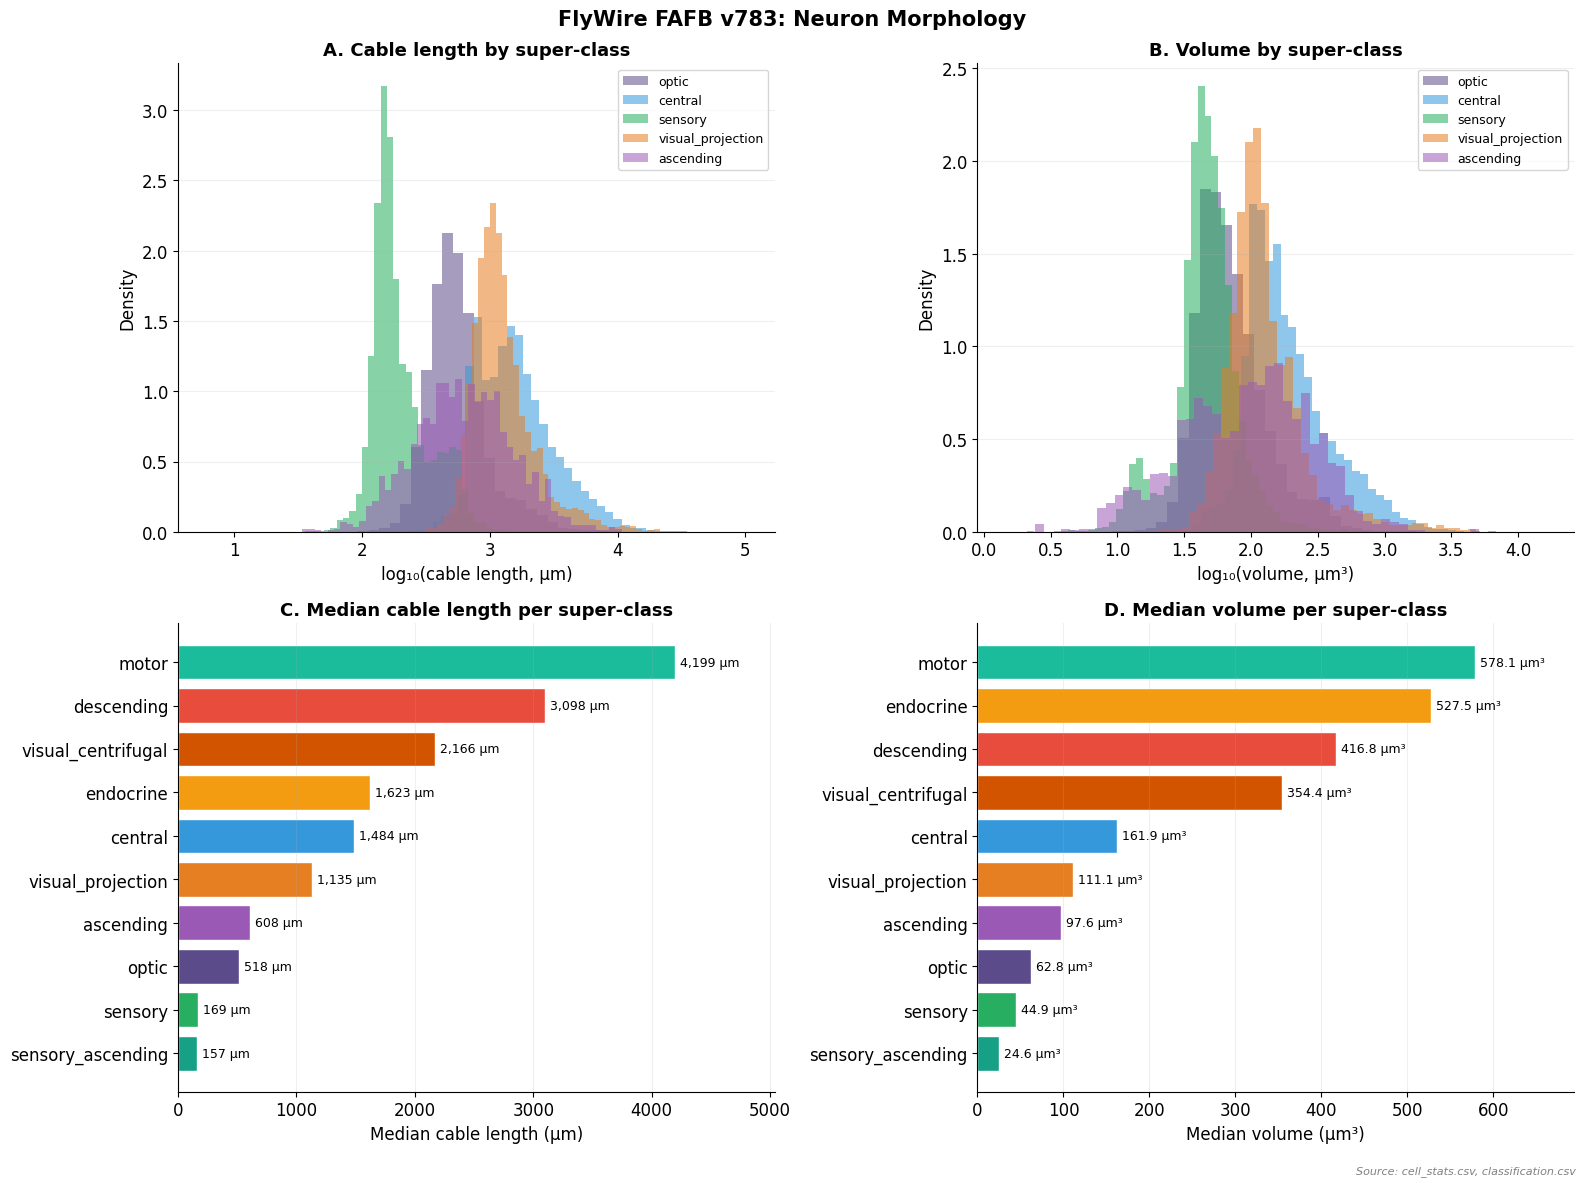

In [ ]:
# STATIC: morphology by super-class — 4 panels
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
top5 = master['super_class'].value_counts().head(5).index.tolist()

# A: Cable length distributions
ax = axes[0, 0]
for sc in top5:
    d = master[(master['super_class']==sc) & master['length_um'].notna()]['length_um']
    if len(d)>50:
        ax.hist(np.log10(d+1), bins=50, alpha=0.55,
                color=PALETTE.get(sc, PALETTE['default']), label=sc, density=True)
ax.set_xlabel('log₁₀(cable length, µm)'); ax.set_ylabel('Density')
ax.set_title('A. Cable length by super-class', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.2)

# B: Volume distributions
ax = axes[0, 1]
for sc in top5:
    d = master[(master['super_class']==sc) & master['volume_um3'].notna()]['volume_um3']
    if len(d)>50:
        ax.hist(np.log10(d+1), bins=50, alpha=0.55,
                color=PALETTE.get(sc, PALETTE['default']), label=sc, density=True)
ax.set_xlabel('log₁₀(volume, µm³)'); ax.set_ylabel('Density')
ax.set_title('B. Volume by super-class', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.2)

# C: Median cable length per super-class
ax = axes[1, 0]
med_len = master.groupby('super_class')['length_um'].median().sort_values(ascending=False).dropna()
bar_cols = [PALETTE.get(sc, PALETTE['default']) for sc in med_len.index]
bars = ax.barh(med_len.index[::-1], med_len.values[::-1], color=bar_cols[::-1], edgecolor='white')
for bar, v in zip(bars, med_len.values[::-1]):
    ax.text(bar.get_width()+med_len.max()*0.01, bar.get_y()+bar.get_height()/2,
            f'{v:,.0f} µm', va='center', fontsize=9)
ax.set_xlabel('Median cable length (µm)')
ax.set_title('C. Median cable length per super-class', fontweight='bold')
ax.set_xlim(0, med_len.max()*1.2); ax.grid(True, axis='x', alpha=0.2)

# D: Median volume per super-class
ax = axes[1, 1]
med_vol = master.groupby('super_class')['volume_um3'].median().sort_values(ascending=False).dropna()
bar_cols = [PALETTE.get(sc, PALETTE['default']) for sc in med_vol.index]
bars = ax.barh(med_vol.index[::-1], med_vol.values[::-1], color=bar_cols[::-1], edgecolor='white')
for bar, v in zip(bars, med_vol.values[::-1]):
    ax.text(bar.get_width()+med_vol.max()*0.01, bar.get_y()+bar.get_height()/2,
            f'{v:.1f} µm³', va='center', fontsize=9)
ax.set_xlabel('Median volume (µm³)')
ax.set_title('D. Median volume per super-class', fontweight='bold')
ax.set_xlim(0, med_vol.max()*1.2); ax.grid(True, axis='x', alpha=0.2)

plt.suptitle('FlyWire FAFB v783: Neuron Morphology', fontsize=15, fontweight='bold')
src('cell_stats.csv, classification.csv')
plt.tight_layout(rect=[0,0.02,1,1])
plt.savefig('eda_outputs/07_morphology.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Neuron Morphology

### What this plot is
This figure describes the **physical size** of neurons across super-classes, using two measurements extracted from the electron microscopy volume: **cable length** (total length of all dendrites and axons combined, in micrometres) and **volume** (how much 3D space the neuron occupies, in cubic micrometres). Both are plotted on a log scale because neuron sizes span several orders of magnitude.

### Panel A & B — Distributions of cable length and volume
These overlaid histograms show the full spread of sizes within each super-class. A few patterns are immediately clear:

- **Sensory neurons** (green) peak sharply at the low end of both plots — very short (~log₁₀ 2.2, roughly 160 µm) and very small in volume. These are compact receptor neurons whose job is simply to transduce a signal, not to integrate across the brain
- **Optic neurons** (purple) cluster tightly around log₁₀ 2.7 (~500 µm), also relatively short — consistent with their role as local processing units within the layered optic lobe
- **Central and visual projection neurons** (blue and orange) are broader and shifted rightward — larger, more variable neurons with longer processes that reach across brain regions
- **Ascending neurons** (lavender) show a wide, flat distribution, reflecting that this is a mixed category spanning very different cell types

The log scale is important: a value of 3 is 10× larger than a value of 2, so the difference between sensory and central neurons is much larger than it visually appears.

### Panel C & D — Median cable length and volume per super-class
These bar charts give a single representative number per super-class, making the size ordering easy to compare.

**The ranking is consistent across both measures:**
- **Motor neurons** are the largest by both cable length (4,199 µm) and volume (578 µm³) — they need long axons to reach muscles in the body
- **Descending neurons** are second (3,098 µm, 416 µm³) — they carry commands from the brain down to the ventral nerve cord and need long projections to do so
- **Visual centrifugal** and **endocrine** neurons are mid-sized
- **Central neurons** sit in the middle (1,484 µm, 161 µm³) — a broad category with moderate average size
- **Optic and sensory neurons** are among the smallest (518 µm and 169 µm respectively), reflecting their compact, locally-wired nature
- **Sensory ascending** neurons are the smallest of all (157 µm, 24.6 µm³)

### Key takeaways for analysis
- Morphology tracks biology: neurons with long-range projection roles (motor, descending) are consistently larger; local processing neurons (sensory, optic) are consistently smaller
- If you are comparing neuron populations and want to control for size, **cable length and volume are strongly correlated with super-class** — differences between groups may partly reflect morphology rather than connectivity
- The tight, unimodal distributions for sensory and optic neurons suggest these are homogeneous populations; the broader distributions for central and ascending neurons reflect their biological diversity
- Motor neurons stand out as outliers in both panels despite being only 110 neurons total — worth keeping in mind if they appear in any whole-brain averages

In [ ]:
# INTERACTIVE: cable length vs volume scatter
# Source: cell_stats.csv + classification.csv + neurons.csv
# Interactive: hover to identify individual neurons; zoom into dense regions.

sdf = master[master['length_um'].notna() & master['volume_um3'].notna() &
              master['super_class'].notna()].sample(min(10000, N), random_state=42)

fig = px.scatter(
    sdf, x='length_um', y='volume_um3',
    color='super_class', color_discrete_map=PALETTE,
    opacity=0.4, log_x=True, log_y=True,
    title='FlyWire FAFB v783: Cable length vs volume — hover to identify neurons<br>'
          '<sub>Source: cell_stats.csv, classification.csv, neurons.csv</sub>',
    labels={'length_um': 'Cable length (µm)', 'volume_um3': 'Volume (µm³)',
            'super_class': 'Super-class'},
    hover_data={'root_id': True, 'length_um': ':.1f', 'volume_um3': ':.2f',
                'class': True, 'nt_type': True, 'primary_type': True},
    height=560
)
fig.update_traces(marker_size=4)
fig.update_layout(legend=dict(itemsizing='constant'))
fig.write_html('eda_outputs/08_morphology_scatter.html', include_plotlyjs='cdn')
fig.show()
print('Saved: eda_outputs/08_morphology_scatter.html')

Saved: eda_outputs/08_morphology_scatter.html


## Cable Length vs Volume Scatter (Interactive)

### What this plot is
This scatter plot shows **every neuron as a single dot**, positioned by its cable length (x-axis, how long its total branching structure is) and its volume (y-axis, how much 3D space it occupies). Both axes are on a log scale. Dots are coloured by super-class. It is the most granular morphology view in the notebook — where the previous figure showed medians and distributions per group, this shows every individual neuron at once.

### How to read it
- **Each dot = one neuron**
- **Further right = longer cable length** (more extensive branching)
- **Higher up = larger volume** (physically bigger cell body and processes)
- **Colour = super-class** (see legend on the right)
- Both axes are logarithmic — moving one tick mark to the right means the neuron is roughly 10× longer, not just a little bit longer

### How to use the interactivity
- **Hover over any dot** to see a tooltip with that neuron's exact measurements and identity. As shown in the screenshot example, hovering reveals:
  - Super-class
  - Cable length (µm)
  - Volume (µm³)
  - `root_id` — the unique neuron ID you can look up in Codex or use in downstream analysis
  - `class` — the cell class (e.g. AN)
  - `nt_type` — predicted neurotransmitter (e.g. ACH)
  - `primary_type` — the specific cell type label (e.g. AN_GNG_187)
- **Click and drag** to zoom into a dense region
- **Click a super-class in the legend** to hide or isolate that group
- **Double-click the legend** to reset to all visible

### What the plot shows

**The strong diagonal trend** confirms that cable length and volume are tightly correlated across the whole brain — bigger neurons have both longer processes and more volume. This is expected biologically and validates the measurements.

**The clusters separate cleanly by super-class:**
- **Sensory neurons** (green, bottom-left) form a tight compact cluster — short cables, small volumes, low variability. These are stereotyped receptor neurons
- **Optic neurons** (purple) cluster just to the right of sensory — small to medium, also relatively homogeneous, consistent with the uniform local-processing cell types in the visual system
- **Central neurons** (blue) spread across the middle-to-right of the plot with high variability — reflecting the biological diversity of central brain cell types
- **Visual projection and visual centrifugal** (orange shades) sit in the mid-to-upper range
- **Descending and ascending** neurons scatter at medium-large sizes
- **The extreme top-right outliers** (largest cable length and volume, beyond 10k µm) are motor neurons — visually obvious as isolated dots far from the main cloud

### Key takeaways for analysis
- Use this plot to **spot outliers** — dots that sit far from their super-class cluster may be mis-classified, unusually large neurons, or biologically interesting edge cases worth investigating
- The `root_id` in the hover tooltip is your direct link to further analysis — you can copy it and query it in Codex or your notebook
- The tight sensory and optic clusters make those super-classes good **negative controls** for morphology comparisons — they are predictable and consistent
- The wide spread of central neurons reflects real biological diversity, not noise — different central brain cell types genuinely differ a lot in size

## 6 — Connectivity: Degree, Hubs & Neuropils
**Source: `connections_princeton.csv.gz`** *(requires Google Drive)*

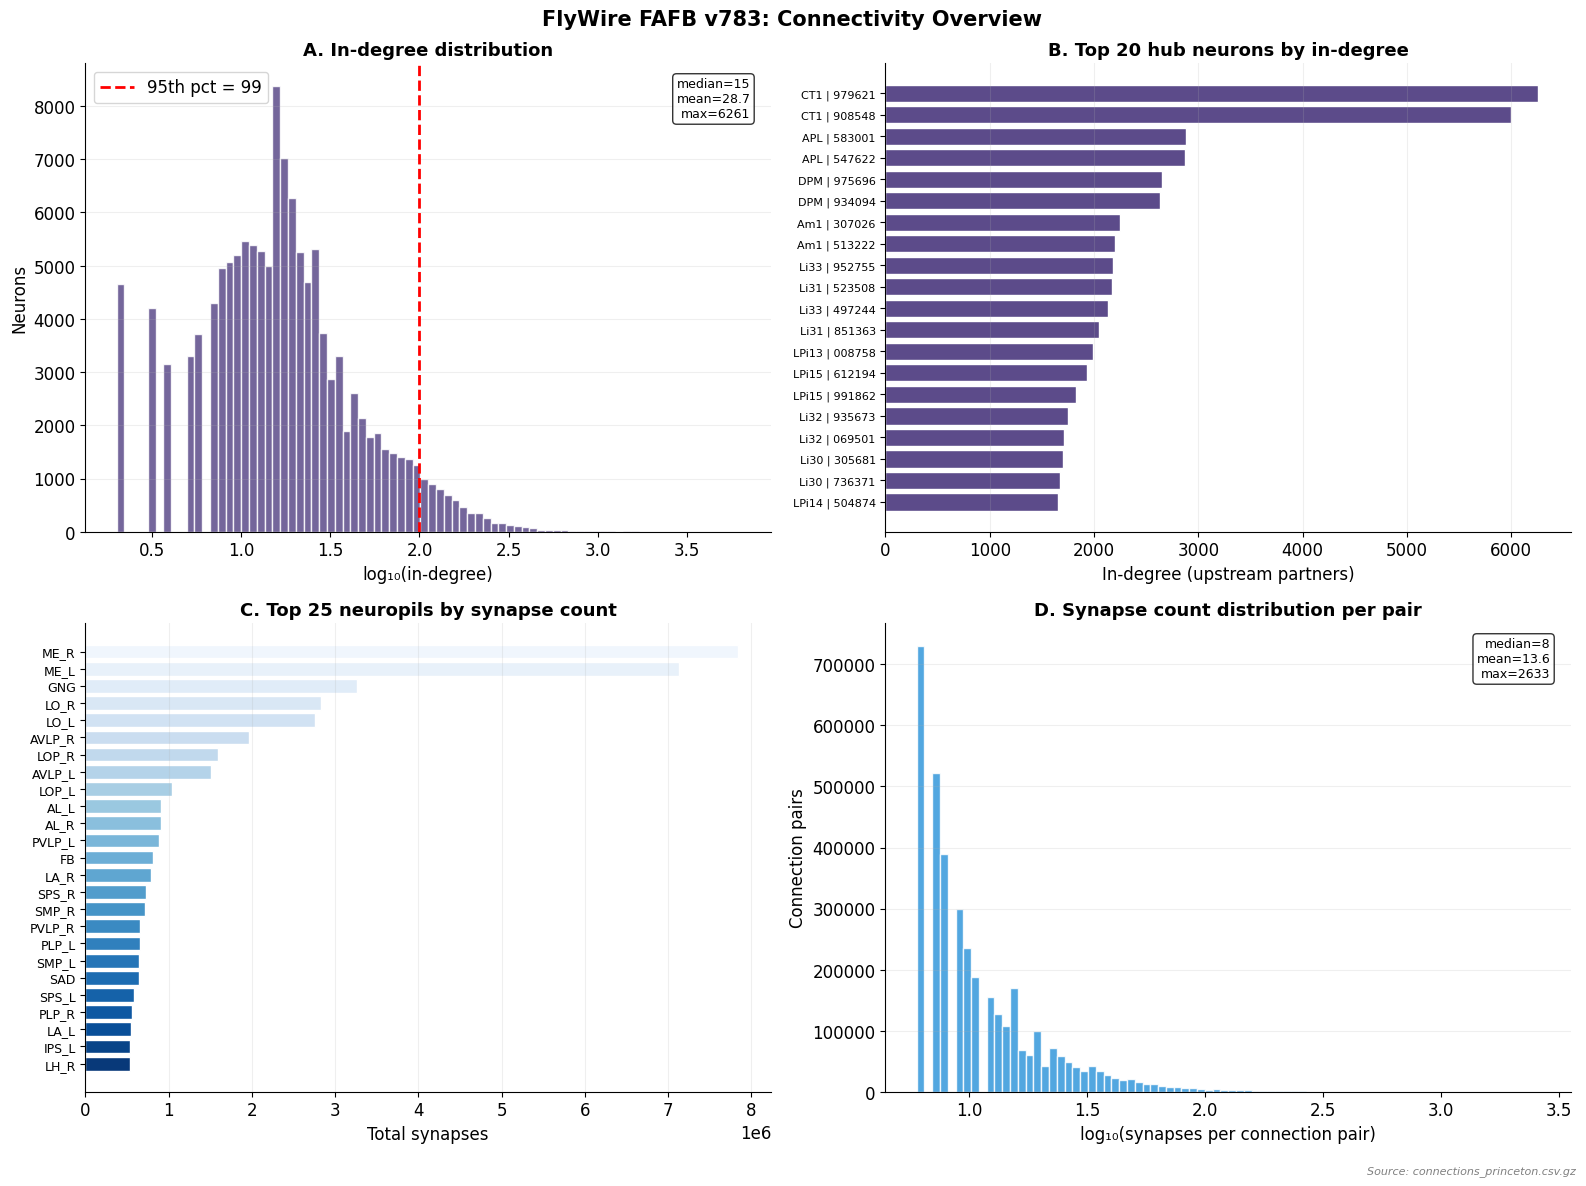

In [ ]:
if not HAS_CONN:
    print('Connections file not loaded — skipping Section 6.')
else:
    # STATIC: degree + neuropil overview — 4 panels
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    p95_in  = master[master['in_degree']>0]['in_degree'].quantile(0.95)
    p95_out = master[master['out_degree']>0]['out_degree'].quantile(0.95)

    # A: In-degree distribution
    ax = axes[0, 0]
    in_data = master[master['in_degree']>0]['in_degree']
    ax.hist(np.log10(in_data+1), bins=80, color='#5C4B8A', edgecolor='white', alpha=0.85)
    ax.axvline(np.log10(p95_in+1), color='red', linestyle='--', linewidth=2,
               label=f'95th pct = {p95_in:.0f}')
    ax.set_xlabel('log₁₀(in-degree)'); ax.set_ylabel('Neurons')
    ax.set_title('A. In-degree distribution', fontweight='bold')
    ax.text(0.97, 0.97,
            f'median={in_data.median():.0f}\nmean={in_data.mean():.1f}\nmax={in_data.max():.0f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.legend(); ax.grid(True, axis='y', alpha=0.2)

    # B: Top 20 hub neurons by in-degree
    ax = axes[0, 1]
    hubs = master.nlargest(20, 'in_degree')
    label_col = next((c for c in ['primary_type','class','super_class']
                      if hubs[c].notna().any()), None)
    hub_labels = (hubs[label_col].fillna('?').str[:20] + ' | ' +
                  hubs['root_id'].astype(str).str[-6:]).values if label_col else \
                 hubs['root_id'].astype(str).str[-10:].values
    ax.barh(hub_labels[::-1], hubs['in_degree'].values[::-1],
            color='#5C4B8A', edgecolor='white')
    ax.set_xlabel('In-degree (upstream partners)')
    ax.set_title('B. Top 20 hub neurons by in-degree', fontweight='bold')
    ax.tick_params(axis='y', labelsize=8); ax.grid(True, axis='x', alpha=0.2)

    # C: Top 25 neuropils by total synapse count
    ax = axes[1, 0]
    np_syn = connections.groupby('neuropil')['syn_count'].sum().nlargest(25)
    ax.barh(np_syn.index[::-1], np_syn.values[::-1],
            color=sns.color_palette('Blues_r', len(np_syn)), edgecolor='white')
    ax.set_xlabel('Total synapses')
    ax.set_title('C. Top 25 neuropils by synapse count', fontweight='bold')
    ax.tick_params(axis='y', labelsize=9); ax.grid(True, axis='x', alpha=0.2)

    # D: Synapse count distribution per connection pair
    ax = axes[1, 1]
    pair_syn = connections.groupby(['pre_root_id','post_root_id'])['syn_count'].sum()
    ax.hist(np.log10(pair_syn+1), bins=80, color='#3498DB', edgecolor='white', alpha=0.85)
    ax.set_xlabel('log₁₀(synapses per connection pair)')
    ax.set_ylabel('Connection pairs')
    ax.set_title('D. Synapse count distribution per pair', fontweight='bold')
    ax.text(0.97, 0.97,
            f'median={pair_syn.median():.0f}\nmean={pair_syn.mean():.1f}\nmax={pair_syn.max():.0f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.grid(True, axis='y', alpha=0.2)

    plt.suptitle('FlyWire FAFB v783: Connectivity Overview', fontsize=15, fontweight='bold')
    src('connections_princeton.csv.gz')
    plt.tight_layout(rect=[0,0.02,1,1])
    plt.savefig('eda_outputs/09_connectivity_overview.pdf', dpi=150, bbox_inches='tight')
    plt.show()

## Connectivity Overview

### What this plot is
This figure characterises the **wiring structure** of the connectome — how neurons are connected to each other, which ones are the most heavily connected hubs, which brain regions have the most synaptic activity, and how strong individual connections tend to be. All four panels draw from the connections table, which records every neuron pair with 5 or more synapses between them.

### Panel A — In-degree distribution
**In-degree** = the number of distinct upstream neurons sending input to a given neuron. This tells you how many different sources of information a neuron receives from.

The x-axis is log₁₀ scale. Key numbers from the inset:
- **Median = 15** — a typical neuron receives input from just 15 upstream partners
- **Mean = 28.7** — the mean is pulled up by high-degree outliers
- **Max = 6,261** — the most-connected neuron receives input from over 6,000 distinct neurons
- **95th percentile = 99** (red dashed line) — only 5% of neurons have more than 99 upstream partners

The distribution is **right-skewed with a long tail** — most neurons are sparsely connected but a small number are extreme hubs. This is characteristic of biological neural networks and means a handful of neurons play disproportionately central roles in information routing.

### Panel B — Top 20 hub neurons by in-degree
The two most connected neurons are both **CT1** type neurons (~6,100 and ~6,000 upstream partners) — these are large tangential neurons in the optic lobe known to integrate signals across wide areas. The next tier includes:
- **APL** (All-neurons Projecting to the Lobes) — a pair of GABAergic neurons that provide feedback inhibition across the entire mushroom body; their extremely high in-degree reflects their brain-wide role
- **DPM** (Dorsal Paired Medial) neurons — neuromodulatory neurons involved in memory consolidation
- **Am1** — amacrine neurons in the optic lobe
- **Li30–Li33, LPi13–LPi15, LPi14** — lobula intrinsic and lobula plate intrinsic neurons, all part of the visual motion processing circuit

The labels show cell type followed by the last 6 digits of the neuron's root_id, to distinguish left and right hemisphere copies of the same type.

### Panel C — Top 25 neuropils by synapse count
**Neuropils** are anatomically defined brain regions where synapses are concentrated. The dominant neuropils are:
- **ME_R and ME_L** (Medulla, right and left) — by far the most synapse-dense regions, consistent with the optic lobe dominating the neuron count
- **GNG** (Gnathal Ganglia) — a large region receiving sensory input from the head
- **LO_R and LO_L** (Lobula) — more visual processing regions
- **AVLP** (Anterior Ventrolateral Protocerebrum) — a central brain region involved in multimodal integration
- **AL** (Antennal Lobe, left and right) — the primary olfactory processing centre
- **FB** (Fan-shaped Body) — central complex structure involved in navigation
- **LH** (Lateral Horn) — processes innate olfactory responses

The left-right symmetry of most neuropil pairs (e.g. ME_R ≈ ME_L) is a reassuring data quality check.

### Panel D — Synapse count distribution per connection pair
This panel asks: when two neurons are connected, how strong is that connection? Strength here = total number of synapses between the pair.

- **Median = 8 synapses** per pair — most connections are weak, just above the 5-synapse threshold used to filter the dataset
- **Mean = 13.6** — pulled up by strong connections
- **Max = 2,633** — the strongest single connection has over 2,600 synapses

The distribution is **heavily left-skewed**: the vast majority of connected pairs share only a handful of synapses, while a small number of pairs have very strong connections. This means synapse count (connection weight) is an important dimension to consider — not all connections in the table are equally meaningful biologically.

### Key takeaways for analysis
- The **median in-degree of 15** suggests most neurons operate as relatively local processors; the long tail of highly-connected hubs is where brain-wide coordination happens
- **CT1 and APL neurons** are the most connected in the dataset and are well-studied — useful reference points for any hub-based analysis
- **Visual regions (ME, LO) dominate synapse counts** — again reflecting the optic lobe's numerical dominance
- When using connection weights, consider filtering to pairs with **≥10 or ≥20 synapses** to focus on physiologically strong connections and reduce noise from weak incidental contacts

In [ ]:
if not HAS_CONN:
    print('Connections file not loaded — skipping degree scatter.')
else:
    # INTERACTIVE: in vs out-degree scatter
    # Source: connections_princeton.csv.gz + classification.csv
    # Interactive: hover to identify specific neurons, zoom into dense regions.

    both = master[(master['in_degree']>0) & (master['out_degree']>0)].copy()
    sdf2 = both.sample(min(8000, len(both)), random_state=42)

    fig = px.scatter(
        sdf2, x='in_degree', y='out_degree',
        color='super_class', color_discrete_map=PALETTE,
        opacity=0.4, log_x=True, log_y=True,
        title='FlyWire FAFB v783: In-degree vs out-degree — hover to identify neurons<br>'
              '<sub>Source: connections_princeton.csv.gz, classification.csv</sub>',
        labels={'in_degree': 'In-degree', 'out_degree': 'Out-degree',
                'super_class': 'Super-class'},
        hover_data={'root_id': True, 'in_degree': ':,d', 'out_degree': ':,d',
                    'in_strength': ':,d', 'primary_type': True,
                    'nt_type': True, 'class': True},
        height=560
    )
    fig.update_traces(marker_size=4)
    fig.update_layout(legend=dict(itemsizing='constant'))
    fig.write_html('eda_outputs/10_degree_scatter.html', include_plotlyjs='cdn')
    fig.show()
    print('Saved: eda_outputs/10_degree_scatter.html')

Saved: eda_outputs/10_degree_scatter.html


## In-degree vs Out-degree Scatter (Interactive)

### What this plot is
This scatter plot places every neuron at the intersection of two connectivity measures: **in-degree** (x-axis, how many distinct neurons send input *to* it) and **out-degree** (y-axis, how many distinct neurons it sends output *to*). Both axes are log scale. A neuron's position in this space reveals its functional role in the network — whether it mainly receives, mainly broadcasts, does both, or does neither.

### How to read it
- **Further right = more upstream partners** (receives from many neurons)
- **Higher up = more downstream partners** (sends to many neurons)
- **Top-right corner** = hub neurons that both receive widely and broadcast widely
- **Bottom-right** = integrators — receive from many but send to few
- **Top-left** = broadcasters — receive from few but send to many
- **Bottom-left** = peripheral neurons with few connections in either direction
- Both axes are log scale — each grid line is a 10× increase, not a fixed step

### How to use the interactivity
- **Hover over any dot** to see a full identity card for that neuron. The tooltip shows:
  - Super-class
  - In-degree and out-degree
  - `root_id` — unique neuron ID for lookup in Codex or further analysis
  - `in_strength` — total number of incoming synapses (not just partner count)
  - `primary_type` — specific cell type label
  - `class` — cell class
- **Click and drag** to zoom into any dense region
- **Click a super-class in the legend** to hide or show that group
- **Double-click the legend** to reset all groups to visible

> ⚠️ **Known display issue:** The hover tooltip currently shows `nt_type=%{customdata[3]}` as literal text instead of the actual NT type value. This is a template formatting bug in the plot code. The other fields (in-degree, out-degree, root_id, primary_type, class) all display correctly.

### What the plot shows

**The main diagonal trend** — in-degree and out-degree are broadly correlated. Neurons that receive a lot tend to send a lot. This is a general property of biological networks and reflects that highly connected neurons serve as routing hubs in both directions.

**Sensory neurons (green) form a vertical stripe at very low in-degree (1–5)** with a wide range of out-degrees. This makes biological sense: sensory receptor neurons receive input from very few upstream sources (essentially just the physical stimulus) but fan out to many downstream processing neurons.

**Central neurons (blue) dominate the upper-right cloud** — high in-degree and high out-degree — consistent with their role as multi-input, multi-output integrators in higher brain circuits.

**Optic neurons (purple) cluster in the middle** — moderate in and out degrees, reflecting the structured, repeating column architecture of the visual system where each neuron has a defined local role.

**The extreme top-right outliers** (in-degree and out-degree both above 1000) are the same hub neurons identified in the previous figure — CT1, APL, and similar brain-wide integrators. They are visually isolated from the main cloud.

**Visual projection and visual centrifugal neurons (orange shades)** tend to sit higher on the out-degree axis relative to their in-degree — they receive from a defined visual input layer and broadcast widely to central brain targets.

### Key takeaways for analysis
- A neuron's **position relative to the diagonal** tells you its role: above the diagonal = broadcaster, below = integrator
- **Zooming into the low in-degree / low out-degree region** (bottom-left) reveals the peripheral neurons — sensory inputs and motor outputs — that anchor the circuit
- The `in_strength` field in the hover (total synapses, not just partner count) is useful for distinguishing neurons with many weak inputs from those with few very strong ones — two neurons at the same x-position can have very different `in_strength` values
- Use this plot to **shortlist candidate neurons** for further study: neurons with unusually high out-degree for their in-degree (high up and to the left) are potential broadcasters worth investigating.

In [ ]:
if not HAS_CONN:
    print('Connections file not loaded — skipping NT heatmap.')
else:
    # INTERACTIVE: pre × post NT synapse heatmap
    # Source: connections_princeton.csv.gz + neurons.csv
    # Interactive: hover for exact synapse counts — a printed heatmap at this
    # resolution would require a magnifying glass.

    nt_map = master.set_index('root_id')['nt_type'].to_dict()
    conn2 = connections.copy()
    conn2['pre_nt']  = conn2['pre_root_id'].map(nt_map)
    conn2['post_nt'] = conn2['post_root_id'].map(nt_map)
    conn2 = conn2.dropna(subset=['pre_nt','post_nt'])
    conn2 = conn2[conn2['pre_nt'].isin(NT_COLORS) & conn2['post_nt'].isin(NT_COLORS)]

    hm = conn2.groupby(['pre_nt','post_nt'])['syn_count'].sum().unstack(fill_value=0)
    order = hm.sum(axis=1).sort_values(ascending=False).index
    hm = hm.reindex(index=order, columns=order, fill_value=0)
    hm_log = np.log10(hm + 1)

    fig = px.imshow(
        hm_log, color_continuous_scale='Purples',
        title='FlyWire FAFB v783: Total synapses — pre-synaptic NT × post-synaptic NT (log₁₀)<br>'
              '<sub>Hover for exact synapse counts. '
              'Source: connections_princeton.csv.gz, neurons.csv</sub>',
        labels=dict(x='Post-synaptic NT', y='Pre-synaptic NT', color='log₁₀(synapses)'),
        text_auto='.1f', aspect='auto'
    )
    fig.update_traces(
        customdata=hm.values,
        hovertemplate='Pre: <b>%{y}</b> → Post: <b>%{x}</b><br>'
                      'Synapses: <b>%{customdata:,}</b><br>'
                      'log₁₀: %{z:.2f}<extra></extra>'
    )
    fig.update_layout(height=480, margin=dict(t=110,b=60,l=80,r=80))
    fig.write_html('eda_outputs/11_nt_synapse_heatmap.html', include_plotlyjs='cdn')
    fig.show()
    print('Saved: eda_outputs/11_nt_synapse_heatmap.html')

Saved: eda_outputs/11_nt_synapse_heatmap.html


## Pre × Post NT Synapse Heatmap (Interactive)

### What this plot is
This heatmap maps the **total number of synapses flowing between every combination of neurotransmitter types** in the connectome. Each cell answers the question: across all connections where the sending neuron uses NT type X and the receiving neuron uses NT type Y, how many total synapses exist? It is the highest-level summary of the brain's chemical communication architecture.

### How to read it
- **Rows = pre-synaptic NT type** — the neurotransmitter used by the sending neuron
- **Columns = post-synaptic NT type** — the neurotransmitter used by the receiving neuron
- **Cell colour and number = log₁₀ of total synapse count** — darker purple means more synapses
- The numbers shown are log₁₀ values: 7.1 means ~12.6 million synapses, 6.1 means ~1.26 million, 3.0 means ~1,000

### How to use the interactivity
Hover over any cell to see the exact values. The tooltip shows three things:
- **Pre and post NT types** (e.g. Pre: GABA → Post: GLUT)
- **Exact synapse count** (e.g. Synapses: 1,498,058)
- **log₁₀ value** (e.g. log₁₀: 6.18)

This is why the plot is interactive — the log scale makes it impossible to read precise differences from colour alone. Hovering reveals the actual numbers, which differ by orders of magnitude.

### What the heatmap shows

**The top-left 3×3 block (ACH, GABA, GLUT) is overwhelmingly dominant** — these three NT types account for the vast majority of all synapses in the connectome. This makes sense: they are also the most common NT types by neuron count.

**ACH → ACH (7.1, ~12.6M synapses)** is the single largest cell, reflecting that excitatory neurons are the most numerous and most connected type in the brain. Excitatory neurons talking to other excitatory neurons drives the bulk of information flow.

**GABA → ACH (6.8) and GABA → GLUT (6.2)** are the next strongest — inhibitory GABA neurons heavily target both excitatory types, which is consistent with GABA's role as a broad brake on circuit activity.

**GLUT → ACH (6.6) and GLUT → GLUT (6.1)** show that glutamate, the second inhibitory type, also primarily targets excitatory neurons.

**The right three columns (SER, DA, OCT) are much lighter** — modulatory neurotransmitters form far fewer total synapses. This reflects both their smaller neuron counts and the fact that neuromodulators often signal via volume transmission (diffuse release) rather than precise point-to-point synapses.

**The diagonal is not especially prominent** — unlike the NT probability heatmap, there is no reason to expect NT types to preferentially synapse onto neurons of the same type. The pattern here is driven by neuron abundance and connectivity, not chemical matching.

### Key takeaways for analysis
- The brain's synapse budget is heavily concentrated in ACH↔ACH, GABA→ACH, and GLUT↔ACH interactions — these are the core excitatory/inhibitory balancing acts
- **Hover is essential here** — the log scale compresses a 10,000-fold range into similar-looking colours. Two cells that look nearly the same shade can differ by 100× in actual synapse count
- Modulatory NT rows (SER, DA, OCT) have 100–1,000× fewer synapses than the main three — worth keeping in mind if you filter by NT type and then count connections, since the sample sizes are very different
- The strong GABA→ACH signal is directly relevant to inhibitory neuron analysis: GABA neurons predominantly target excitatory (ACH) neurons, which is the expected circuit motif for feedback inhibition

## 7 — Network Topology Roles
**Source: `connectivity_tags.csv`, `classification.csv`, `neurons.csv`**

Connectivity tag counts:
  Rich-club            60,848  (43.7%)
  Reciprocal          102,757  (73.8%)
  Feedforward         132,167  (94.9%)
  3-cycle              86,671  (62.2%)


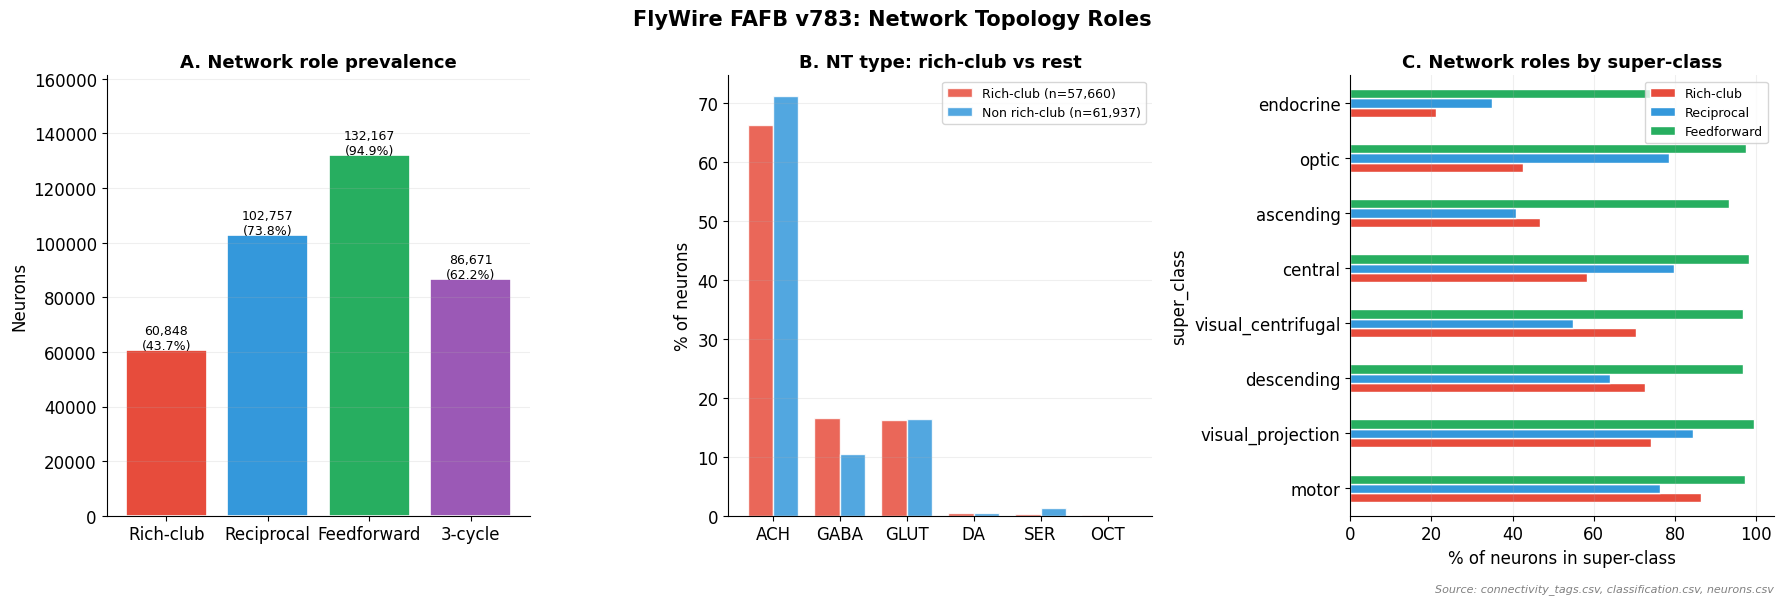

In [ ]:
if conn_tags.empty or 'rich_club' not in master.columns:
    print('Connectivity tags not loaded — skipping.')
else:
    print('Connectivity tag counts:')
    for tag, col in [('Rich-club','rich_club'),('Reciprocal','reciprocal'),
                     ('Feedforward','feedforward'),('3-cycle','cycle_3')]:
        n_t = master[col].sum()
        print(f'  {tag:<18} {n_t:>8,}  ({100*n_t/N:.1f}%)')

    # STATIC: 3 panels
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # A: Tag prevalence
    ax = axes[0]
    tags = ['Rich-club','Reciprocal','Feedforward','3-cycle']
    cols = ['rich_club','reciprocal','feedforward','cycle_3']
    counts = [master[c].sum() for c in cols]
    bars = ax.bar(tags, counts,
                  color=['#E74C3C','#3498DB','#27AE60','#9B59B6'],
                  edgecolor='white', linewidth=1.2)
    for bar, v in zip(bars, counts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+N*0.002,
                f'{v:,}\n({100*v/N:.1f}%)', ha='center', fontsize=9)
    ax.set_ylabel('Neurons'); ax.set_title('A. Network role prevalence', fontweight='bold')
    ax.set_ylim(0, max(counts)*1.22); ax.grid(True, axis='y', alpha=0.2)

    # B: Rich-club vs non-rich-club NT breakdown
    ax = axes[1]
    rc  = master[master['rich_club'] & master['nt_type'].isin(NT_COLORS)]
    nrc = master[~master['rich_club'] & master['nt_type'].isin(NT_COLORS)]
    nt_order = list(NT_COLORS.keys())
    rc_pct  = rc['nt_type'].value_counts(normalize=True)*100
    nrc_pct = nrc['nt_type'].value_counts(normalize=True)*100
    x = np.arange(len(nt_order)); w = 0.38
    ax.bar(x-w/2, [rc_pct.get(n,0)  for n in nt_order], w, color='#E74C3C',
           alpha=0.85, label=f'Rich-club (n={len(rc):,})', edgecolor='white')
    ax.bar(x+w/2, [nrc_pct.get(n,0) for n in nt_order], w, color='#3498DB',
           alpha=0.85, label=f'Non rich-club (n={len(nrc):,})', edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(nt_order)
    ax.set_ylabel('% of neurons'); ax.set_title('B. NT type: rich-club vs rest', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.2)

    # C: Tag rates by super-class
    ax = axes[2]
    sc_tag = (master.groupby('super_class')[['rich_club','reciprocal','feedforward']]
              .mean()*100).sort_values('rich_club', ascending=False).head(8)
    sc_tag.columns = ['Rich-club','Reciprocal','Feedforward']
    sc_tag.plot(kind='barh', ax=ax, color=['#E74C3C','#3498DB','#27AE60'], edgecolor='white')
    ax.set_xlabel('% of neurons in super-class')
    ax.set_title('C. Network roles by super-class', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, axis='x', alpha=0.2)

    plt.suptitle('FlyWire FAFB v783: Network Topology Roles', fontsize=15, fontweight='bold')
    src('connectivity_tags.csv, classification.csv, neurons.csv')
    plt.tight_layout(rect=[0,0.02,1,1])
    plt.savefig('eda_outputs/12_network_topology.pdf', dpi=150, bbox_inches='tight')
    plt.show()

## Network Topology Roles

### What this plot is
Beyond simply counting connections, the connectome can be analysed for **structural motifs** — recurring patterns of connectivity that reveal how information is organised at the network level. This figure uses four such tags assigned to each neuron in `connectivity_tags.csv`:

- **Rich-club**: neurons that are more heavily interconnected with each other than expected by chance — a densely wired inner core that likely coordinates brain-wide activity
- **Reciprocal**: neurons that have at least one bidirectional connection (A→B and B→A) — suggesting feedback and mutual influence between partners
- **Feedforward**: neurons that participate in a feedforward loop motif (A→B→C and A→C directly) — a common circuit element for signal amplification and coincidence detection
- **3-cycle**: neurons in a 3-neuron recurrent loop (A→B→C→A) — associated with oscillations and sustained activity

### Panel A — Network role prevalence
The most striking finding is how widespread these roles are:
- **Feedforward (94.9%, 132,167 neurons)** — nearly every neuron in the dataset participates in at least one feedforward loop. This suggests feedforward architecture is a near-universal feature of fly brain wiring, not a specialised motif
- **Reciprocal (73.8%, 102,757 neurons)** — almost three quarters of neurons have at least one bidirectional connection, meaning feedback is extremely common throughout the connectome
- **3-cycle (62.2%, 86,671 neurons)** — over half of neurons participate in recurrent loops, pointing to widespread capacity for sustained or oscillatory activity
- **Rich-club (43.7%, 60,848 neurons)** — nearly half of neurons qualify as rich-club members, which is high and suggests the fly brain has a very dense, heavily interconnected core rather than a small elite hub

### Panel B — NT type: rich-club vs non-rich-club
This panel compares the NT composition of rich-club neurons (red) against non-rich-club neurons (blue).

The most notable difference is in **GABA**: rich-club neurons have ~17% GABA compared to ~11% in non-rich-club neurons. Rich-club neurons are disproportionately inhibitory. This makes functional sense — a densely interconnected core would need strong local inhibition to prevent runaway excitation and to gate information flow selectively.

**ACH is slightly lower in rich-club neurons** (67% vs 71%) despite being the dominant NT overall, suggesting the rich-club core has a subtly different excitatory/inhibitory balance than the rest of the network.

**GLUT proportions are similar** between the two groups (~16–17%), and modulatory types (DA, SER, OCT) are negligible in both.

### Panel C — Network roles by super-class
This panel shows what fraction of each super-class participates in each of the three main roles (rich-club, reciprocal, feedforward).

**Feedforward (green) is near 100% for almost every super-class** — confirming that feedforward loops are a universal feature regardless of cell type.

**Reciprocal (blue) varies more:**
- Highest in **motor, descending, visual_projection, central** (~65–85%) — these are the brain's long-range projection systems where feedback between partners is most functionally meaningful
- Lower in **optic** (~75%) — still high but slightly less than projection neurons

**Rich-club (red) shows the most variation:**
- **Endocrine neurons** have low rich-club membership (~45%) — they are output neurons that broadcast hormonal signals and may not need dense recurrent wiring
- **Optic neurons** have relatively low rich-club membership (~40%) — consistent with the visual system being a more feedforward, hierarchical processing structure
- **Central, ascending, descending** neurons have higher rich-club membership, reflecting their role in integrating signals across the brain
- **Motor neurons** stand out with very low rich-club membership (~5%) — motor output neurons sit at the end of processing chains and are not part of the recurrent core

### Key takeaways for analysis
- The near-universal feedforward and reciprocal tags mean these alone are not useful for distinguishing neuron populations — nearly everything qualifies
- **Rich-club membership is the most discriminating tag**, varying meaningfully across super-classes and NT types
- The enrichment of GABA in rich-club neurons is a specific, testable prediction: inhibitory neurons may play a disproportionate role in coordinating the brain's central hub
- **Motor neurons being largely outside the rich-club** confirms they are output terminals, not integrators — a good sanity check that the topology tags are biologically meaningful

## 8 — Inhibitory Neuron Deep-Dive
**Source: `neurons.csv`, `classification.csv`, `cell_stats.csv`, `connectivity_tags.csv`**

Inhibitory (GABA+Glut): 35,622 (25.6%)
Excitatory (ACh):       82,298 (59.1%)


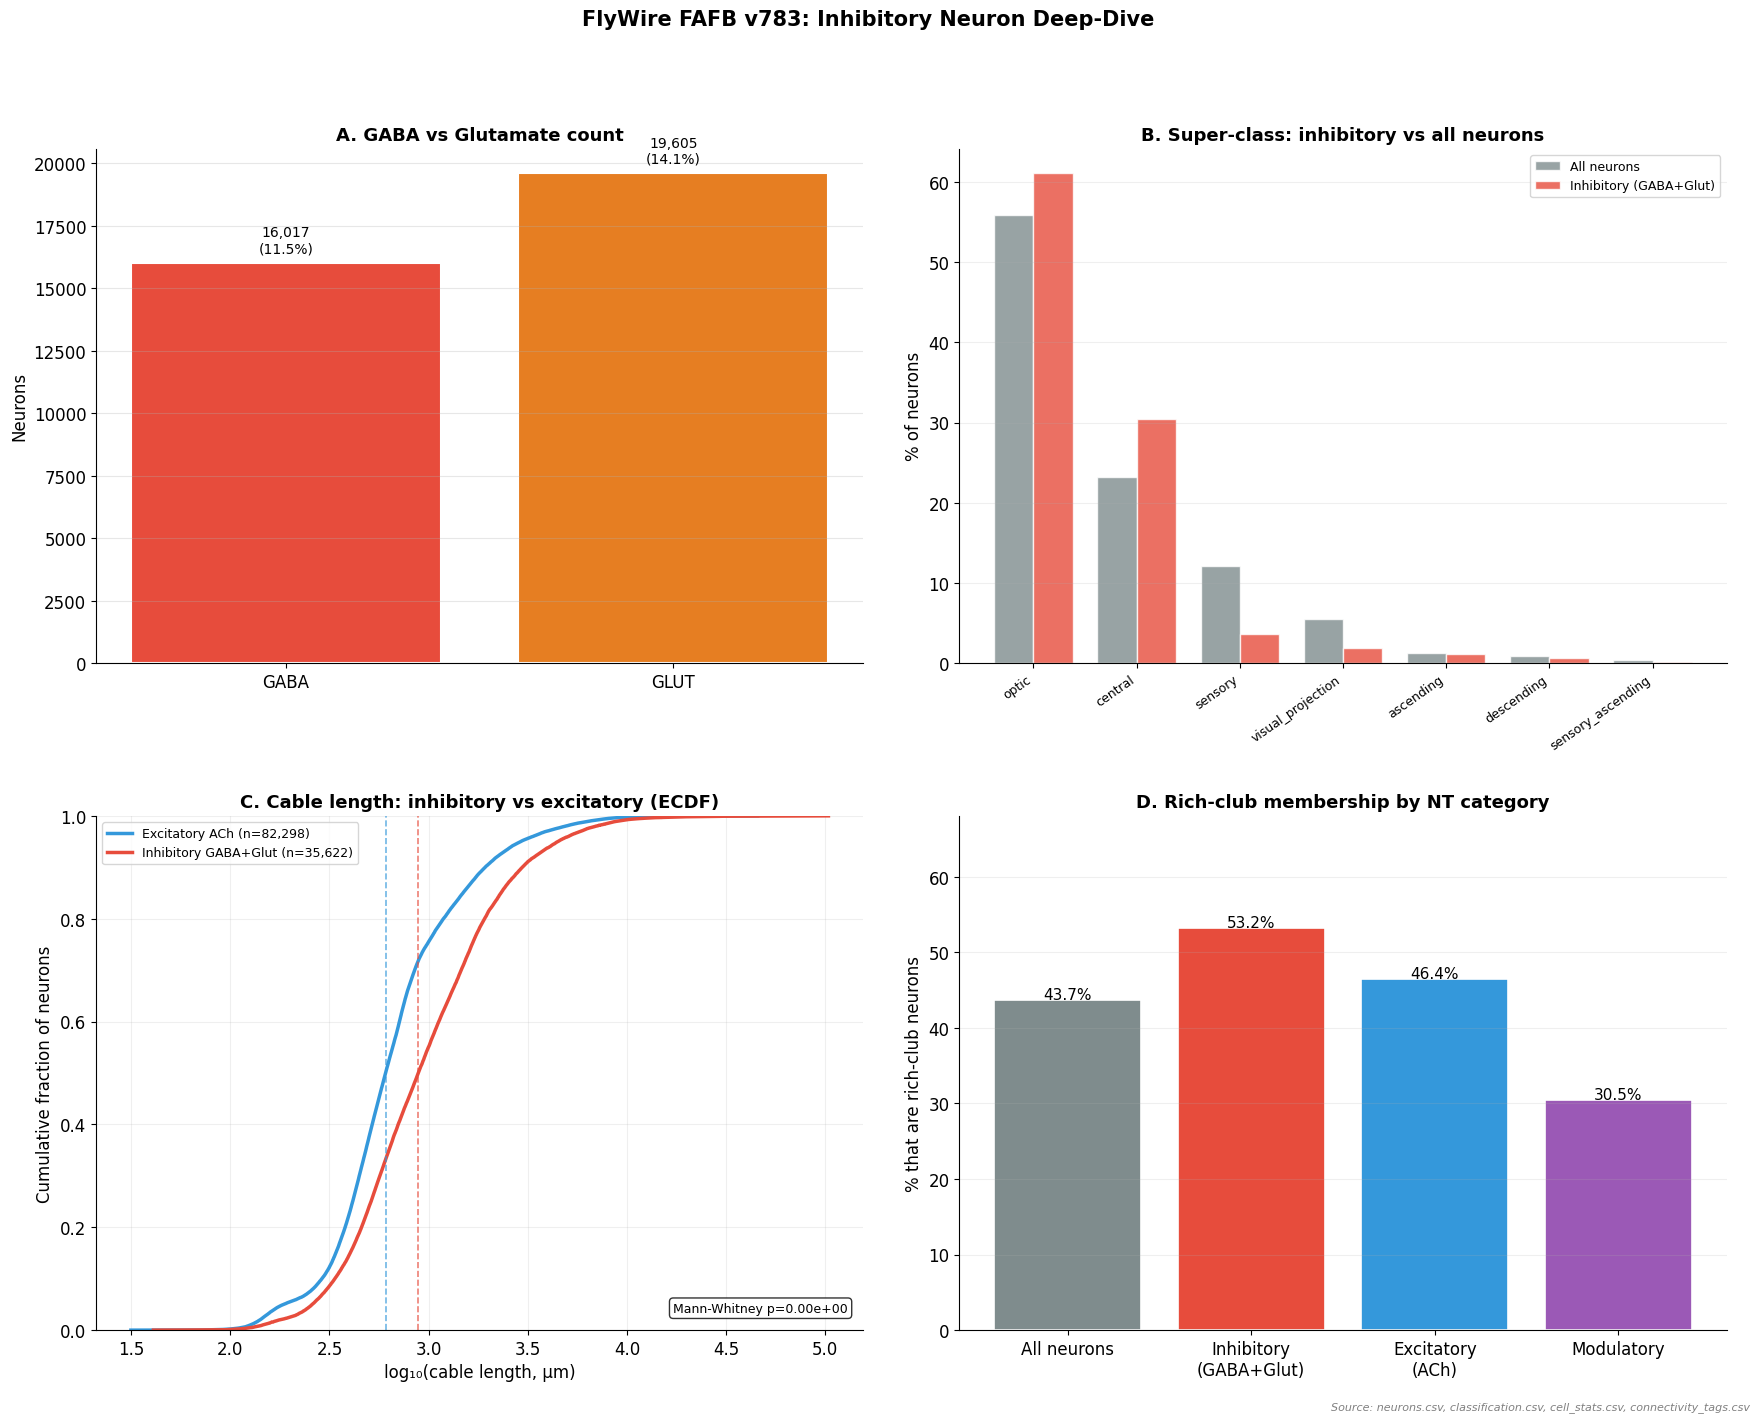

In [40]:
inhib = master[master['nt_type'].isin(INHIBITORY)]
excit = master[master['nt_type'].isin(EXCITATORY)]
print(f'Inhibitory (GABA+Glut): {len(inhib):,} ({100*len(inhib)/N:.1f}%)')
print(f'Excitatory (ACh):       {len(excit):,} ({100*len(excit)/N:.1f}%)')

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# A: GABA vs Glut
ax = axes[0, 0]
for i, (nt, col) in enumerate([('GABA','#E74C3C'),('GLUT','#E67E22')]):
    cnt = (master['nt_type']==nt).sum()
    ax.bar(nt, cnt, color=col, edgecolor='white', linewidth=1.5)
    ax.text(i, cnt+N*0.003, f'{cnt:,}\n({100*cnt/N:.1f}%)', ha='center', fontsize=10)
ax.set_ylabel('Neurons'); ax.set_title('A. GABA vs Glutamate count', fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

# B: Super-class composition — inhibitory vs all
ax = axes[0, 1]
sc_all   = master['super_class'].value_counts(normalize=True)*100
sc_inhib = inhib['super_class'].value_counts(normalize=True)*100
sc_ord   = sc_all.head(7).index
x = np.arange(len(sc_ord)); w = 0.38
ax.bar(x-w/2, [sc_all.get(s,0)   for s in sc_ord], w, color='#7F8C8D',
       alpha=0.8, label='All neurons', edgecolor='white')
ax.bar(x+w/2, [sc_inhib.get(s,0) for s in sc_ord], w, color='#E74C3C',
       alpha=0.8, label='Inhibitory (GABA+Glut)', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(sc_ord, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('% of neurons')
ax.set_title('B. Super-class: inhibitory vs all neurons', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.2)

# C: Cable length comparison — ECDF
ax = axes[1, 0]
for data, color, label in [
    (excit['length_um'].dropna(), '#3498DB', f'Excitatory ACh (n={len(excit):,})'),
    (inhib['length_um'].dropna(), '#E74C3C', f'Inhibitory GABA+Glut (n={len(inhib):,})'),
]:
    sorted_data = np.sort(np.log10(data + 1))
    y = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    ax.plot(sorted_data, y, color=color, linewidth=2.5, label=label)

for data, color in [
    (excit['length_um'].dropna(), '#3498DB'),
    (inhib['length_um'].dropna(), '#E74C3C'),
]:
    med = np.log10(data.median() + 1)
    ax.axvline(med, color=color, linestyle='--', linewidth=1.2, alpha=0.7)

ax.set_xlabel('log₁₀(cable length, µm)')
ax.set_ylabel('Cumulative fraction of neurons')
ax.set_title('C. Cable length: inhibitory vs excitatory (ECDF)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.2); ax.set_ylim(0, 1)
u, p = stats.mannwhitneyu(
    inhib['length_um'].dropna(), excit['length_um'].dropna(), alternative='two-sided'
)
ax.text(0.98, 0.03, f'Mann-Whitney p={p:.2e}', transform=ax.transAxes,
        ha='right', va='bottom', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# D: Rich-club membership by NT category
ax = axes[1, 1]
if 'rich_club' in master.columns:
    modu = master[master['nt_type'].isin(MODULATORY)]
    cats = ['All neurons', 'Inhibitory\n(GABA+Glut)', 'Excitatory\n(ACh)', 'Modulatory']
    vals = [100*master['rich_club'].mean(), 100*inhib['rich_club'].mean(),
            100*excit['rich_club'].mean(),  100*modu['rich_club'].mean()]
    cols = ['#7F8C8D', '#E74C3C', '#3498DB', '#9B59B6']
    bars = ax.bar(cats, vals, color=cols, edgecolor='white', linewidth=1.2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{v:.1f}%', ha='center', fontsize=11)
    ax.set_ylabel('% that are rich-club neurons')
    ax.set_title('D. Rich-club membership by NT category', fontweight='bold')
    ax.set_ylim(0, max(vals)*1.28)
    ax.grid(True, axis='y', alpha=0.2)

plt.suptitle('FlyWire FAFB v783: Inhibitory Neuron Deep-Dive',
             fontsize=15, fontweight='bold', y=1.01)
src('neurons.csv, classification.csv, cell_stats.csv, connectivity_tags.csv')
plt.tight_layout(pad=2.5)
plt.savefig('eda_outputs/13_inhibitory_deepdive.pdf', dpi=150, bbox_inches='tight')
plt.show()

## Inhibitory Neuron Deep-Dive

### What this plot is
This figure zooms in specifically on the **inhibitory neurons** — those using GABA or glutamate as their neurotransmitter — and asks how they differ from the rest of the brain in terms of their distribution across brain regions, their physical size, and their structural role in the network. Inhibitory neurons are particularly relevant to the lab's research focus, as they provide the braking and gating mechanisms that shape circuit dynamics.

### Panel A — GABA vs Glutamate count
There are two distinct types of inhibitory neuron in the fly brain:
- **GABA (16,017, 11.5%)** — the classical inhibitory neurotransmitter, directly suppresses activity in target neurons
- **Glutamate (19,605, 14.1%)** — in invertebrates, glutamate can act as an inhibitory neurotransmitter (unlike in vertebrates where it is primarily excitatory), particularly at neuromuscular junctions and in visual processing circuits

Glutamate-using inhibitory neurons are slightly more numerous than GABA neurons in this dataset. Combined they make up **25.6% of all neurons** — roughly one in four neurons in the fly brain is inhibitory.

### Panel B — Super-class: inhibitory vs all neurons
This panel compares the super-class distribution of inhibitory neurons (red) against all neurons (grey). The differences are biologically informative:

- **Optic**: inhibitory neurons are *overrepresented* here (61% of inhibitory neurons vs 56% of all neurons) — the visual system uses inhibition heavily for contrast enhancement, direction selectivity, and motion detection
- **Central**: inhibitory neurons are *also overrepresented* (30% vs 23%) — central brain circuits require substantial inhibition for gating, selection, and timing of behaviours like memory retrieval and navigation
- **Sensory**: inhibitory neurons are strongly *underrepresented* (4% vs 12%) — sensory input neurons are predominantly excitatory, as their job is to relay signals forward, not suppress them
- **Visual projection, ascending, descending**: all underrepresented in the inhibitory population — these long-range projection systems are predominantly excitatory

The key takeaway: **inhibitory neurons are concentrated where computation happens** (optic lobe and central brain) and sparse where signals are being transmitted (sensory periphery and long-range projections).

### Panel C — Cable length: inhibitory vs excitatory (ECDF)
This panel uses a **cumulative distribution function (ECDF)** to compare the physical size of inhibitory (GABA+Glut, red) and excitatory (ACh, blue) neurons. Rather than showing density estimates, the ECDF shows the exact proportion of neurons with cable length at or below each value — every data point is represented precisely with no smoothing.

**How to read it:** At any point on the x-axis, the y-value tells you what fraction of neurons in that group have a cable length at or below that value. A curve that rises steeply and early (shifted left) means that group has shorter neurons overall. The dashed vertical lines mark the median cable length for each group.

**What it shows:**
- The **inhibitory curve (red) rises earlier and faster** than the excitatory curve — inhibitory neurons are systematically shorter. At log₁₀ = 2.8 (~630 µm), roughly 60% of inhibitory neurons fall below that length, compared to only ~45% of excitatory neurons
- The **excitatory curve (blue) has a longer right tail** — it rises more slowly at the high end, reflecting the many long-range ACh projection neurons with cables extending to 10,000+ µm
- The **medians diverge visibly**: the red dashed line sits noticeably to the left of the blue, confirming inhibitory neurons are on average more compact
- The two curves **converge at the extremes** — very short and very long neurons exist in both populations

The **Mann-Whitney p=0.00e+00** confirms this size difference is highly statistically significant across nearly 120,000 neurons combined — this is a genuine biological difference, not noise. Inhibitory neurons being more compact is consistent with their role as local interneurons that operate within a brain region rather than projecting long distances across it.

### Panel D — Rich-club membership by NT category
This panel asks whether inhibitory neurons are disproportionately part of the brain's densely connected core. The bars show what percentage of each NT category qualifies as a rich-club neuron — a neuron that is more heavily interconnected with other high-degree neurons than expected by chance.

- **All neurons (43.7%)** — the baseline: just under half the brain is rich-club
- **Inhibitory (GABA+Glut): 53.2%** — significantly enriched above baseline. More than half of all inhibitory neurons belong to the rich-club, making them the most hub-like NT category
- **Excitatory (ACh): 46.4%** — slightly above baseline but considerably less enriched than inhibitory neurons
- **Modulatory (DA/SER/OCT): 30.5%** — well below baseline, consistent with modulatory neurons being diffuse volume broadcasters rather than point-to-point circuit elements

The x-axis labels use line breaks to keep the panel readable — "Inhibitory (GABA+Glut)" and "Excitatory (ACh)" are each shown on two lines.

The enrichment of inhibitory neurons in the rich-club is one of the most analytically important findings in this EDA. It suggests that **inhibitory neurons are not peripheral modulators but central, well-connected members of the brain's core processing architecture** — they are wired into the most heavily trafficked circuits, not just providing background suppression on the sidelines.

### Key takeaways for analysis
- Glutamate is more numerous than GABA in this dataset — worth distinguishing them in analyses rather than treating all inhibitory neurons as a single group
- Inhibitory neurons are concentrated in optic and central super-classes — filtering to `super_class == 'central'` and `nt_type.isin(['GABA','GLUT'])` gives the most circuit-relevant inhibitory population for follow-up work
- Inhibitory neurons are physically smaller and more compact than excitatory neurons — consistent with a local interneuron role rather than long-range projection
- The 53.2% rich-club membership is a strong signal that inhibitory neurons deserve central attention in any connectivity analysis, not just as background elements

## 9 — Community Annotations
**Source: `labels.csv`**

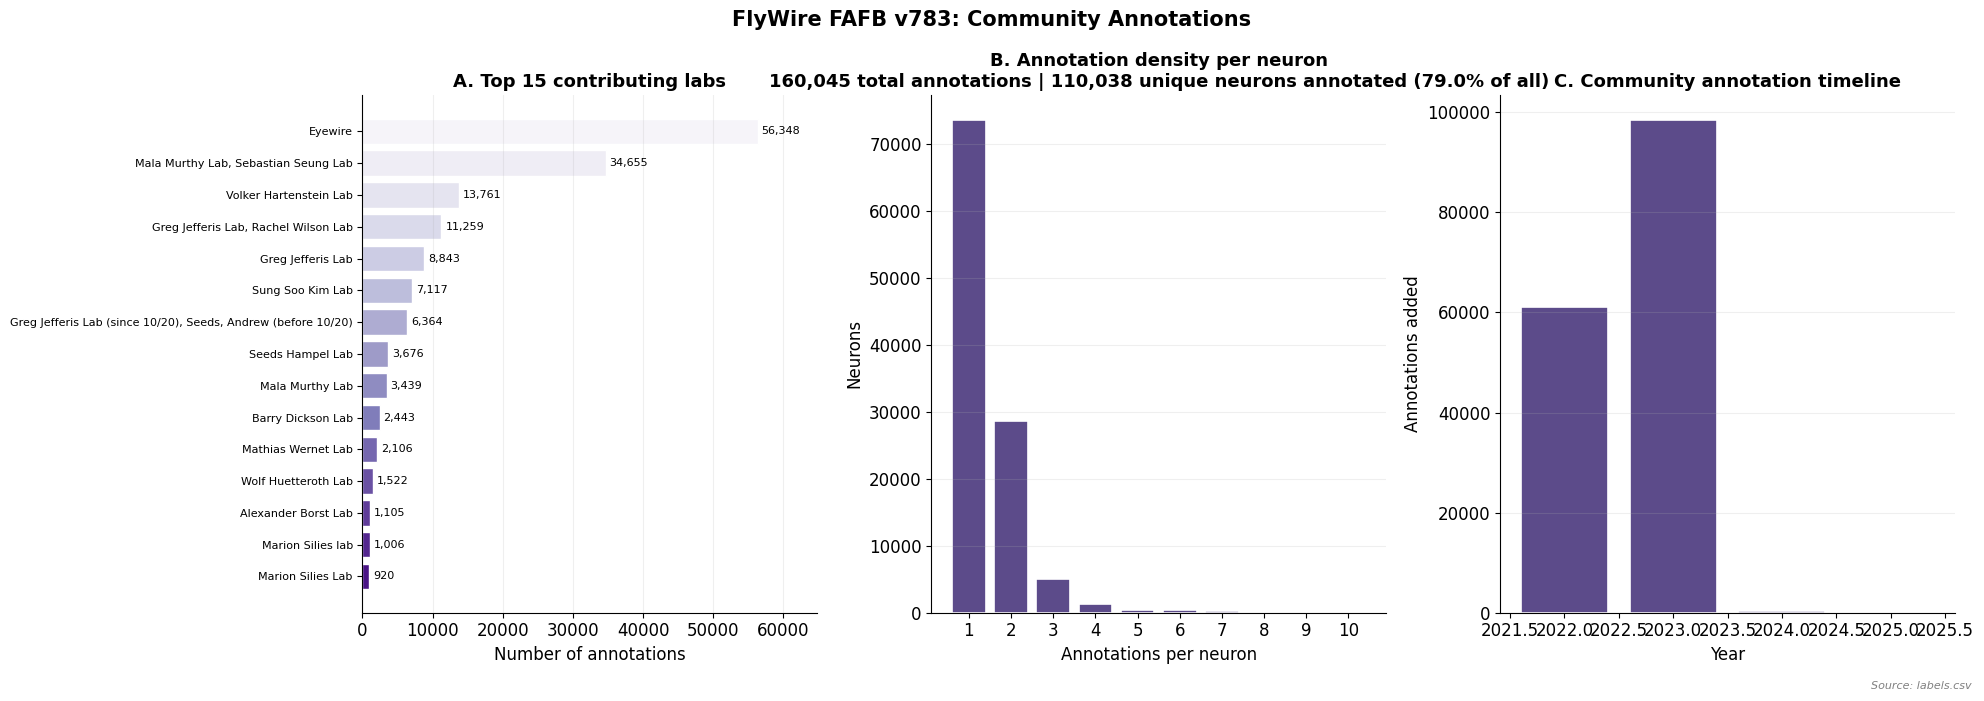

In [ ]:
if labels.empty:
    print('labels.csv not loaded — skipping.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    # A: Top 15 contributing labs
    ax = axes[0]
    lab_c = labels['user_affiliation'].str.strip().value_counts().head(15)
    bars = ax.barh(lab_c.index[::-1], lab_c.values[::-1],
                   color=sns.color_palette('Purples_r', len(lab_c)), edgecolor='white')
    for bar, v in zip(bars, lab_c.values[::-1]):
        ax.text(bar.get_width()+lab_c.max()*0.01, bar.get_y()+bar.get_height()/2,
                f'{v:,}', va='center', fontsize=8)
    ax.set_xlabel('Number of annotations')
    ax.set_title('A. Top 15 contributing labs', fontweight='bold')
    ax.set_xlim(0, lab_c.max()*1.15)
    ax.tick_params(axis='y', labelsize=8); ax.grid(True, axis='x', alpha=0.2)

    # B: Annotations per neuron
    ax = axes[1]
    ann_per = labels.groupby('root_id').size()
    n_total = len(labels); n_uniq = labels['root_id'].nunique()
    hist_data = ann_per.value_counts().sort_index().head(10)
    ax.bar(hist_data.index.astype(str), hist_data.values,
           color='#5C4B8A', edgecolor='white', linewidth=1.2)
    ax.set_xlabel('Annotations per neuron'); ax.set_ylabel('Neurons')
    ax.set_title(f'B. Annotation density per neuron\n'
                 f'{n_total:,} total annotations | {n_uniq:,} unique neurons annotated '
                 f'({100*n_uniq/N:.1f}% of all)', fontweight='bold')
    ax.grid(True, axis='y', alpha=0.2)

    # C: Annotation timeline by year
    ax = axes[2]
    labels['year'] = pd.to_datetime(labels['date_created'], errors='coerce').dt.year
    yr = labels.groupby('year').size().dropna()
    ax.bar(yr.index.astype(int), yr.values, color='#5C4B8A', edgecolor='white', linewidth=1.2)
    ax.set_xlabel('Year'); ax.set_ylabel('Annotations added')
    ax.set_title('C. Community annotation timeline', fontweight='bold')
    ax.grid(True, axis='y', alpha=0.2)

    plt.suptitle('FlyWire FAFB v783: Community Annotations', fontsize=15, fontweight='bold')
    src('labels.csv')
    plt.tight_layout(rect=[0,0.02,1,1])
    plt.savefig('eda_outputs/14_community_annotations.pdf', dpi=150, bbox_inches='tight')
    plt.show()

## Community Annotations

### What this plot is
The FlyWire connectome is not just a wiring diagram — it is also a **community-annotated resource**. Hundreds of scientists from labs around the world have contributed labels to individual neurons, tagging them with names, cell type identities, and biological roles. This figure characterises that annotation effort: who contributed, how thoroughly neurons were labelled, and when the work happened. The data comes from `labels.csv`, which records every annotation ever submitted, by whom, and when.

### Panel A — Top 15 contributing labs
Annotation contributions are highly concentrated:
- **Eyewire (56,348 annotations)** is the single largest contributor — Eyewire is a citizen science platform where non-expert volunteers trace and annotate neurons as a game. This represents a massive crowdsourced effort
- **Mala Murthy Lab / Sebastian Seung Lab (34,655)** — the two Princeton labs that built and lead FlyWire, responsible for a large fraction of the expert annotations
- **Volker Hartenstein Lab (13,761)** — a Drosophila neuroanatomy lab known for systematic brain region classifications
- **Greg Jefferis Lab / Rachel Wilson Lab (11,259)** and **Greg Jefferis Lab (8,843)** — the Jefferis lab at MRC Cambridge led the hierarchical cell type annotation effort behind the Schlegel et al. paper; these entries reflect different contributor groupings over time
- **Sung Soo Kim Lab (7,117)**, **Seeds Hampel Lab (3,676)**, **Barry Dickson Lab (2,443)**, and others — specialised labs contributing annotations in their areas of expertise

The long tail of smaller labs (1,000–3,500 annotations each) reflects a broad community of specialists who each annotated the neuron types relevant to their research.

### Panel B — Annotation density per neuron
**160,045 total annotations cover 110,038 unique neurons (79.0% of all neurons).**

The distribution is sharply right-skewed:
- ~75,000 neurons have exactly **1 annotation** — they have been labelled once, likely with a basic identity tag
- ~29,000 neurons have **2 annotations** — a second annotator has independently confirmed or extended the first label
- ~5,000 have **3 annotations**, and progressively fewer have more
- A small number have up to 10 annotations — these are usually well-studied neuron types that multiple labs have independently labelled

The rapid drop-off means **most neurons have only a single annotation with no independent verification**. For neurons with only one label, there is no built-in cross-check for errors.

### Panel C — Community annotation timeline
The annotation effort has a clear history:
- **2022** saw ~60,000 annotations — the initial large-scale community push coinciding with the first FlyWire data release and early publication preprints
- **2023** saw the largest single-year contribution (~95,000+ annotations) — corresponding to the peer review and publication period of the flagship Dorkenwald and Schlegel Nature papers, when intense community annotation drove the dataset toward completion
- **2024 and 2025** show a sharp drop-off — the major annotation effort has concluded; only incremental additions are being made

This timeline confirms that the dataset is **essentially mature** — the bulk of the annotation work was done in 2022–2023 to support publication, and the labels are unlikely to change substantially going forward.

### Key takeaways for analysis
- **79% neuron coverage** is high but not complete — the 21% of unannotated neurons are worth inspecting to understand whether they represent a biased sample (e.g. unusual or hard-to-classify neurons)
- **Most neurons have only one annotation** — if you are relying on community labels for a specific biological claim, check whether the neuron has been annotated by multiple independent contributors; single-annotation labels carry more uncertainty
- **Lab-of-origin is available** in the labels table — if you need annotations from a specific area of expertise (e.g. olfactory circuit labels from the Wilson Lab, or visual circuit labels from the Borst Lab), you can filter by `user_affiliation`
- The **Eyewire citizen science contribution** is large in number but covers different neuron types than expert lab annotations — worth being aware of when interpreting label provenance
- The dataset is **effectively frozen** as of 2024 — you do not need to worry about labels changing between analyses

## 10 — Visual Neuron Types (Optic Lobe)
**Source: `visual_neuron_types.csv`, `column_assignment.csv`, `cell_stats.csv`**

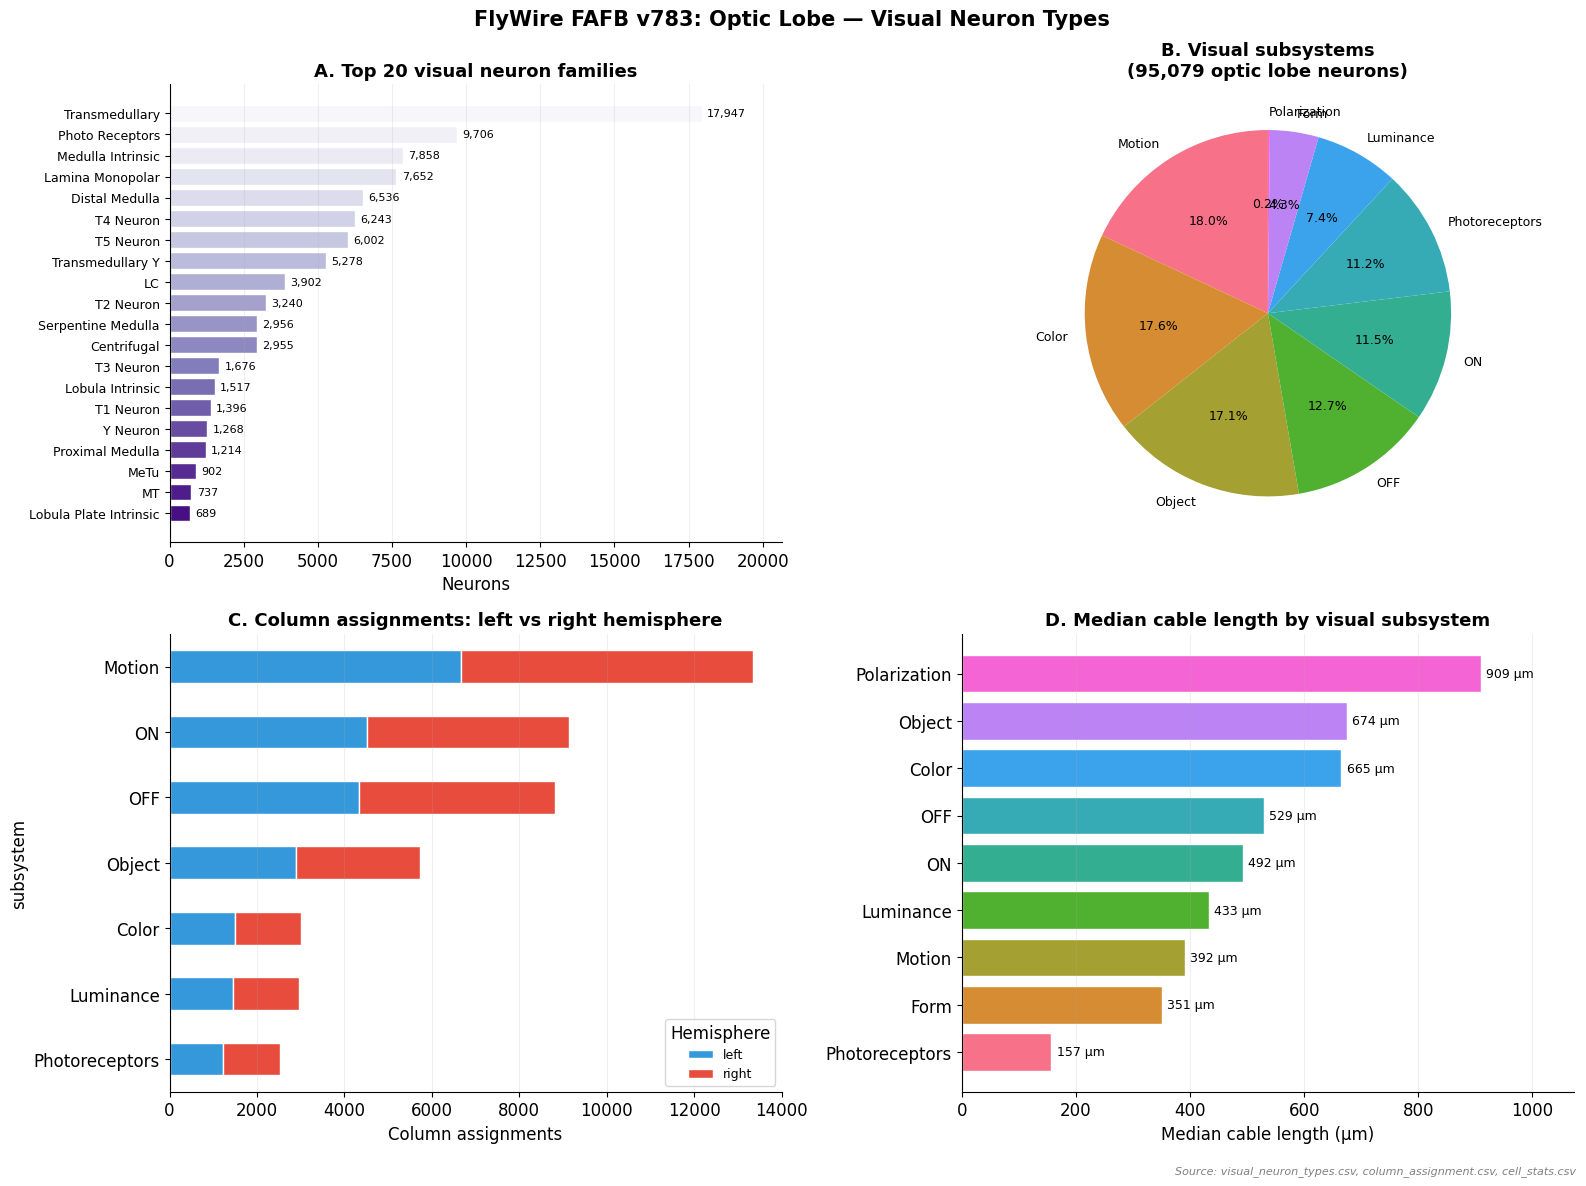

In [ ]:
if visual_types.empty:
    print('visual_neuron_types.csv not loaded — skipping.')
else:
    # Enrich visual_types with morphology
    vt = visual_types.copy()
    if not cell_stats.empty:
        vt = vt.merge(cell_stats, on='root_id', how='left')
        vt['length_um']  = vt['length_nm']  / 1_000
        vt['volume_um3'] = vt['size_nm']    / 1_000_000_000

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # A: Top 20 optic lobe cell families
    ax = axes[0, 0]
    fam = vt['family'].value_counts().head(20)
    bars = ax.barh(fam.index[::-1], fam.values[::-1],
                   color=sns.color_palette('Purples_r', len(fam)), edgecolor='white')
    for bar, v in zip(bars, fam.values[::-1]):
        ax.text(bar.get_width()+fam.max()*0.01, bar.get_y()+bar.get_height()/2,
                f'{v:,}', va='center', fontsize=8)
    ax.set_xlabel('Neurons'); ax.set_title('A. Top 20 visual neuron families', fontweight='bold')
    ax.set_xlim(0, fam.max()*1.15); ax.grid(True, axis='x', alpha=0.2)
    ax.tick_params(axis='y', labelsize=9)

    # B: Visual subsystem distribution
    ax = axes[0, 1]
    sub_sys = vt['subsystem'].value_counts().dropna()
    sub_sys = sub_sys[sub_sys.index.str.strip() != '']
    colors_sub = sns.color_palette('husl', len(sub_sys))
    ax.pie(sub_sys.values, labels=sub_sys.index, autopct='%1.1f%%',
           startangle=90, colors=colors_sub,
           textprops={'fontsize': 9})
    ax.set_title(f'B. Visual subsystems\n({len(vt):,} optic lobe neurons)',
                 fontweight='bold')

    # C: Left vs right hemisphere count per subsystem
    ax = axes[1, 0]
    if not col_assign.empty:
        hemi = col_assign['hemisphere'].value_counts()
        col_sub = col_assign.merge(vt[['root_id','subsystem']], on='root_id', how='left')
        hemi_sub = (col_sub.dropna(subset=['subsystem'])
                    .groupby(['subsystem','hemisphere']).size().unstack(fill_value=0))
        hemi_sub = hemi_sub.reindex(columns=['left','right'], fill_value=0)
        hemi_sub['total'] = hemi_sub.sum(axis=1)
        hemi_sub = hemi_sub.sort_values('total', ascending=True).drop(columns='total')
        hemi_sub.plot(kind='barh', stacked=True, ax=ax,
                      color=['#3498DB','#E74C3C'], edgecolor='white')
        ax.set_xlabel('Column assignments')
        ax.set_title('C. Column assignments: left vs right hemisphere', fontweight='bold')
        ax.legend(title='Hemisphere', fontsize=9)
        ax.grid(True, axis='x', alpha=0.2)

    # D: Median cable length by visual subsystem
    ax = axes[1, 1]
    if 'length_um' in vt.columns:
        med_vt = (vt.dropna(subset=['subsystem','length_um'])
                  [vt['subsystem'].str.strip() != '']
                  .groupby('subsystem')['length_um']
                  .median().sort_values(ascending=False))
        bars = ax.barh(med_vt.index[::-1], med_vt.values[::-1],
                       color=sns.color_palette('husl', len(med_vt)), edgecolor='white')
        for bar, v in zip(bars, med_vt.values[::-1]):
            ax.text(bar.get_width()+med_vt.max()*0.01, bar.get_y()+bar.get_height()/2,
                    f'{v:,.0f} µm', va='center', fontsize=9)
        ax.set_xlabel('Median cable length (µm)')
        ax.set_title('D. Median cable length by visual subsystem', fontweight='bold')
        ax.set_xlim(0, med_vt.max()*1.18); ax.grid(True, axis='x', alpha=0.2)

    plt.suptitle('FlyWire FAFB v783: Optic Lobe — Visual Neuron Types',
                 fontsize=15, fontweight='bold')
    src('visual_neuron_types.csv, column_assignment.csv, cell_stats.csv')
    plt.tight_layout(rect=[0,0.02,1,1])
    plt.savefig('eda_outputs/15_visual_neuron_types.pdf', dpi=150, bbox_inches='tight')
    plt.show()

## Optic Lobe — Visual Neuron Types

### What this plot is
This figure focuses exclusively on the **95,079 neurons of the optic lobe** — the visual processing system that makes up 55.9% of the entire connectome. The optic lobe is not a single structure but a series of layered neuropils (lamina, medulla, lobula, lobula plate) that process visual information in parallel streams. This figure breaks that population down by neuron family, visual function, hemisphere, and physical size using `visual_neuron_types.csv` and `column_assignment.csv`.

### Panel A — Top 20 visual neuron families
Neurons in the optic lobe are organised into stereotyped cell type families based on their morphology and connectivity:

- **Transmedullary (17,947)** — the largest family, neurons that connect the medulla to deeper optic lobe layers. They carry signals across processing stages and are involved in multiple visual computations
- **Photo Receptors (9,706)** — the R1-R8 photoreceptor axon terminals bringing raw light information from the compound eye into the optic lobe
- **Medulla Intrinsic (7,858)** and **Lamina Monopolar (7,652)** — local processing neurons within the medulla and lamina respectively, the first two layers of visual processing
- **Distal Medulla (6,536)** — neurons in the outer medulla, involved in early spatial and temporal filtering
- **T4 Neuron (6,243) and T5 Neuron (6,002)** — direction-selective motion detection neurons, among the most studied in all of fly neuroscience. T4 detects ON-motion (light edges moving), T5 detects OFF-motion (dark edges moving)
- **Transmedullary Y (5,278)** — a specific subtype of transmedullary neurons
- **LC neurons (3,902)** — Lobula Columnar neurons that project to the central brain and are involved in detecting visual features like small moving objects

The large numbers of T4/T5, Transmedullary, and Lamina Monopolar neurons reflect the highly regular, retinotopic column structure of the optic lobe — each of the ~700 columns in each eye contains one copy of many of these cell types.

### Panel B — Visual subsystems
The 95,079 optic lobe neurons are grouped into functional subsystems based on what visual computation they perform:

- **Motion (18.0%)** — direction-selective neurons detecting movement, including T4/T5 and downstream circuits
- **Object (17.1%)** — neurons involved in detecting and tracking discrete visual objects
- **Color (17.6%)** — neurons processing wavelength information for colour vision
- **OFF (12.7%)** — neurons responding to decrements in light intensity (dark edges)
- **ON (11.5%)** — neurons responding to increments in light intensity (bright edges)
- **Luminance (7.4%)** — neurons encoding overall light level rather than spatial detail
- **Photoreceptors (11.2%)** — the input layer, not yet functionally specialised
- **Form (small slice)** — neurons involved in detecting shape and spatial patterns
- **Polarization (0.2%)** — a tiny but specialised population detecting the polarisation angle of light, used for navigation

The near-equal division between Motion, Object, and Color as the three largest subsystems reflects the fly's visual priorities: detecting movement (predators, prey, mates), identifying objects, and using colour for navigation and foraging.

### Panel C — Column assignments: left vs right hemisphere
This panel uses `column_assignment.csv`, which records which retinotopic column each neuron belongs to — essentially its position within the regular grid structure of the optic lobe.

**Left and right hemispheres are strikingly symmetric** across every subsystem. Motion has the most column assignments (~6,200 left, ~7,200 right) reflecting the large T4/T5 populations. The slight right > left asymmetry visible in Motion and ON may reflect a minor annotation imbalance rather than a biological asymmetry. This symmetry is a strong data quality indicator and also means that analyses of one hemisphere should generalise to the other.

### Panel D — Median cable length by visual subsystem
Physical size varies meaningfully by visual function:

- **Polarization neurons (909 µm)** are the longest — these neurons connect the dorsal rim area of the eye to deeper processing regions, requiring long-range projections
- **Object (674 µm) and Color (665 µm)** neurons are also large, reflecting their need to integrate signals across wider spatial areas
- **OFF (529 µm) and ON (492 µm)** neurons are mid-sized
- **Motion neurons (392 µm)** are relatively compact — T4/T5 neurons are local to the medulla/lobula plate and do not need long projections
- **Photoreceptors (157 µm)** are the shortest — they are essentially short axon stubs delivering signals from the retina into the first processing layer

The size gradient from photoreceptors to higher-order processing neurons mirrors the functional hierarchy: neurons closer to the input are small and local; neurons carrying processed information downstream are larger and more extensively branched.

### Key takeaways for analysis
- The optic lobe has a **highly regular, reproducible structure** — the column symmetry and tight cell type families make it ideal for quantitative comparative analyses
- **T4 and T5 neurons** (combined ~12,245 neurons) are the gateway to motion processing and among the best-characterised neurons in any invertebrate connectome — strong starting points for circuit analysis
- The **subsystem labels** in `visual_neuron_types.csv` are a useful filter: `subsystem == 'Motion'` gives a clean, biologically coherent population for connectivity analysis
- When **excluding the optic lobe** from whole-brain analyses (to avoid it dominating results), filtering `super_class != 'optic'` removes all 77,873 optic neurons cleanly

In [ ]:
# Register datasets
FLYWIRE_CONFIG = {'name': 'FlyWire FAFB v783', 'color': '#5C4B8A'}

ALL_NEURONS     = [master]
ALL_CONNECTIONS = [connections] if HAS_CONN else [pd.DataFrame()]
ALL_CONFIGS     = [FLYWIRE_CONFIG]

def build_comparison_dashboard(
    all_neurons, all_connections, all_configs,
    save_path='eda_outputs/comparison_dashboard.html'
):
    colors   = {cfg['name']: cfg['color'] for cfg in all_configs}
    datasets = [cfg['name'] for cfg in all_configs]
    neurons_all = pd.concat(all_neurons, ignore_index=True)

    fig = make_subplots(
        rows=3, cols=2,
        subplot_titles=[
            'A. In-degree distribution (log scale)',
            'B. NT type proportions',
            'C. Median in-degree by NT type',
            'D. Annotation completeness',
            'E. In-degree vs out-degree (hover to identify)',
            'F. Top cell classes',
        ],
        vertical_spacing=0.12,
        horizontal_spacing=0.10,
        specs=[
            [{'type': 'xy'},      {'type': 'bar'}],
            [{'type': 'bar'},     {'type': 'heatmap'}],
            [{'type': 'scatter'}, {'type': 'bar'}],
        ]
    )

    nt_types = (
        neurons_all['nt_type']
        .value_counts()
        .drop('Unknown', errors='ignore')
        .dropna()
        .index.tolist()
    ) if 'nt_type' in neurons_all.columns else []

    for i, (ndf, cdf, cfg) in enumerate(zip(all_neurons, all_connections, all_configs)):
        name = cfg['name']
        col  = cfg['color']

        # Detect the neuron ID column
        id_col = 'root_id' if 'root_id' in ndf.columns else 'neuron_id'

        # A: In-degree distribution
        if 'in_degree' in ndf.columns:
            in_data = ndf[ndf['in_degree'] > 0]['in_degree']
            fig.add_trace(go.Histogram(
                x=np.log10(in_data + 1), nbinsx=70,
                name=name, opacity=0.65, marker_color=col,
                legendgroup=name, showlegend=True,
                histnorm='probability density',
                hovertemplate=f'<b>{name}</b><br>log₁₀(in-degree): %{{x:.2f}}<br>Density: %{{y:.4f}}<extra></extra>'
            ), row=1, col=1)

        # B: NT proportions
        if 'nt_type' in ndf.columns and nt_types:
            nt_pct = ndf['nt_type'].value_counts(normalize=True) * 100
            fig.add_trace(go.Bar(
                x=nt_types, y=[nt_pct.get(nt, 0) for nt in nt_types],
                name=name, marker_color=col,
                legendgroup=name, showlegend=False,
                hovertemplate=f'<b>{name}</b><br>%{{x}}: %{{y:.1f}}%<extra></extra>'
            ), row=1, col=2)

        # C: Median in-degree by NT type
        if 'nt_type' in ndf.columns and 'in_degree' in ndf.columns and nt_types:
            med = (
                ndf[ndf['in_degree'] > 0]
                .groupby('nt_type')['in_degree']
                .median()
                .drop('Unknown', errors='ignore')
                .reindex(nt_types)
            )
            fig.add_trace(go.Bar(
                x=nt_types, y=med.values,
                name=name, marker_color=col,
                legendgroup=name, showlegend=False,
                hovertemplate=f'<b>{name}</b><br>%{{x}}: median in-degree %{{y:.0f}}<extra></extra>'
            ), row=2, col=1)

        # E: In vs out-degree scatter
        if 'in_degree' in ndf.columns and 'out_degree' in ndf.columns:
            both = ndf[(ndf['in_degree'] > 0) & (ndf['out_degree'] > 0)]
            s    = both.sample(min(3000, len(both)), random_state=42)
            label_col = next(
                (c for c in ['primary_type', 'class', 'super_class']
                 if c in s.columns and s[c].notna().any()), None
            )
            hover_label = s[label_col].fillna('?') if label_col else pd.Series(['?']*len(s), index=s.index)
            nt_hover    = s['nt_type'].fillna('?') if 'nt_type' in s.columns else pd.Series(['?']*len(s), index=s.index)
            fig.add_trace(go.Scatter(
                x=s['in_degree'], y=s['out_degree'],
                mode='markers',
                marker=dict(color=col, size=4, opacity=0.35),
                name=name, legendgroup=name, showlegend=False,
                customdata=np.stack([
                    hover_label,
                    s[id_col].astype(str),
                    nt_hover,
                ], axis=1),
                hovertemplate=(
                    f'<b>{name}</b><br>'
                    'Type: %{customdata[0]}<br>'
                    'ID: %{customdata[1]}<br>'
                    'NT: %{customdata[2]}<br>'
                    'In-degree: %{x:,}<br>'
                    'Out-degree: %{y:,}<extra></extra>'
                )
            ), row=3, col=1)

        # F: Top cell classes
        class_col = 'class' if 'class' in ndf.columns else 'cell_class'
        if class_col in ndf.columns and ndf[class_col].notna().any():
            top_cc = neurons_all[class_col].value_counts().dropna().head(10).index.tolist()
            cc_pct = ndf[class_col].value_counts(normalize=True) * 100
            fig.add_trace(go.Bar(
                x=top_cc, y=[cc_pct.get(c, 0) for c in top_cc],
                name=name, marker_color=col,
                legendgroup=name, showlegend=False,
                hovertemplate=f'<b>{name}</b><br>%{{x}}: %{{y:.1f}}%<extra></extra>'
            ), row=3, col=2)

    # D: Annotation completeness heatmap
    ann_fields = ['super_class', 'class', 'primary_type',
                  'nt_type', 'side', 'flow', 'hemilineage']
    ann_fields = [f for f in ann_fields if f in neurons_all.columns]
    hm_z = [
        [round(100 * ndf[f].notna().mean(), 1) for f in ann_fields]
        for ndf in all_neurons
    ]
    fig.add_trace(go.Heatmap(
        z=hm_z, x=ann_fields, y=datasets,
        colorscale='Greens', zmin=0, zmax=100,
        text=[[f'{v:.0f}%' for v in row] for row in hm_z],
        texttemplate='%{text}',
        colorbar=dict(title='% annotated', len=0.28, y=0.5),
        hovertemplate='<b>%{y}</b><br>%{x}: %{z:.1f}% annotated<extra></extra>'
    ), row=2, col=2)

    # Axis labels
    fig.update_xaxes(title_text='log₁₀(in-degree)',     row=1, col=1)
    fig.update_yaxes(title_text='Probability density',  row=1, col=1)
    fig.update_xaxes(title_text='Neurotransmitter',     row=1, col=2)
    fig.update_yaxes(title_text='% of neurons',         row=1, col=2)
    fig.update_xaxes(title_text='Neurotransmitter',     row=2, col=1)
    fig.update_yaxes(title_text='Median in-degree',     row=2, col=1)
    fig.update_xaxes(title_text='In-degree',  type='log', row=3, col=1)
    fig.update_yaxes(title_text='Out-degree', type='log', row=3, col=1)
    fig.update_xaxes(title_text='Cell class', tickangle=35, row=3, col=2)
    fig.update_yaxes(title_text='% of neurons',         row=3, col=2)

    fig.update_layout(
        title=dict(
            text=(
                'FlyWire FAFB v783 — Exploration Dashboard<br>'
                '<sub>'
                + ', '.join(datasets)
                + '  ·  Click legend to toggle datasets  ·  '
                  'Hover any point for details  ·  Drag to zoom'
                + '</sub>'
            ),
            x=0.5, font=dict(size=17)
        ),
        height=1380,
        barmode='group',
        template='plotly_white',
        legend=dict(
            title='Dataset', orientation='h',
            yanchor='bottom', y=1.02,
            xanchor='left',   x=0.0,
            font=dict(size=13)
        ),
        margin=dict(t=130, b=60, l=80, r=80),
    )

    fig.write_html(save_path, include_plotlyjs='cdn')
    print(f'\nDashboard saved: {save_path}')
    print('  Self-contained HTML — open in any browser.')
    fig.show()
    return fig


dashboard = build_comparison_dashboard(
    ALL_NEURONS, ALL_CONNECTIONS, ALL_CONFIGS
)


Dashboard saved: eda_outputs/comparison_dashboard.html
  Self-contained HTML — open in any browser.


## Exploration Dashboard

### What this dashboard is
This is a single interactive summary of the entire FlyWire FAFB v783 dataset across six panels. It is designed as the primary **exploration and comparison tool** — when Hemibrain or another dataset is added later, every panel will automatically show both datasets side by side, with the legend letting you toggle each one on and off. Right now it reflects FlyWire alone. All panels are linked through the same legend: clicking "FlyWire FAFB v783" in the top-left hides or shows that dataset across the whole dashboard simultaneously.

---

### Panel A — In-degree distribution (log scale)
This shows the full distribution of how many upstream partners each neuron has, on a log₁₀ x-axis. The distribution has a characteristic shape: a sharp rise peaking around log₁₀ = 1.0–1.3 (roughly 10–20 upstream partners), then a long right tail extending to log₁₀ = 3+ (over 1,000 partners). This heavy-tailed distribution is the fingerprint of a biological neural network — most neurons are sparsely connected local processors, while a small elite of hub neurons integrate signals from across the brain. When Hemibrain is added, its distribution will overlay in a different colour, immediately revealing whether the two datasets have comparable connectivity profiles or systematically different wiring densities.

---

### Panel B — NT type proportions
A bar chart showing what percentage of neurons use each neurotransmitter. ACH dominates at ~68%, followed by GLUT (~16%) and GABA (~13%), with SER, DA, and OCT all under 1% and barely visible. This panel will be most useful in cross-dataset comparison — if Hemibrain's NT proportions differ from FlyWire's, it will appear immediately as different-height bars grouped by NT type. Hover over any bar to see the exact percentage.

---

### Panel C — Median in-degree by NT type
This panel asks a specific functional question: do different neurotransmitter types have different connectivity levels? The answer here is yes, and the pattern is striking. ACH (~12), GLUT (~17), and GABA (~21) neurons have progressively higher median in-degrees — inhibitory neurons receive from more upstream partners than excitatory ones. SER (~4) and DA (~12) are lower. The standout result is **OCT at ~74** — octopamine neurons have an unusually high median in-degree despite being only 72 neurons total. This likely reflects that OCT neurons are neuromodulatory hub neurons that integrate wide input before broadcasting. This panel is directly relevant to the lab's interest in how inhibitory neuron connectivity compares to the rest of the brain.

---

### Panel D — Annotation completeness
This heatmap is a **data quality scorecard** — it tells you which columns you can actually rely on for analysis. Each cell shows the percentage of neurons with a non-null value for that field:

| Field | Coverage | Interpretation |
|-------|----------|----------------|
| `super_class` | 100% | Fully reliable — safe to use as a grouping variable anywhere |
| `class` | 77% | Good but not complete — ~23% of neurons lack a class label |
| `primary_type` | 99% | Essentially complete — cell type is safe to use |
| `nt_type` | 86% | Good — 14% unknown, worth filtering by `nt_type_score` for precision |
| `side` | 100% | Fully reliable |
| `flow` | 100% | Fully reliable |
| `hemilineage` | 27% | Sparse — only use for analyses specifically targeting hemilineage, and be aware of coverage gaps |

When Hemibrain is added, this panel will reveal at a glance which fields exist in both datasets and can support cross-dataset comparisons — any field where one dataset shows near 0% is not usable for comparison.

---

### Panel E — In-degree vs out-degree (hover to identify)
Each dot is a single neuron, positioned by how many neurons send it input (x-axis) and how many it sends output to (y-axis), both on log scales. The strong diagonal trend confirms that neurons receiving more input also tend to send more output — connectivity is correlated across directions. The vertical stripe of dots at low in-degree (left side) are sensory neurons that receive from very few sources but fan out to many targets. The upper-right cluster is the hub population that both integrates and broadcasts widely. Hovering over any individual dot reveals its cell type, root ID, NT type, and exact degree values — this is the main tool for identifying specific neurons of interest for follow-up analysis. Drag to zoom into any dense region.

---

### Panel F — Top cell classes
A bar chart of the ten most numerous cell classes as a percentage of the total. `optic_lobe_intrinsic` accounts for ~70% of all neurons, dwarfing everything else. The next tier — `visual` (~9%), `Kenyon_Cell` (~4%), `CX` (~2%) — are all biologically important but small relative to the visual system. This panel makes the optic lobe dominance concrete in one glance and reinforces the importance of filtering by super-class before making whole-brain generalizations. When Hemibrain is added, differences in population composition will be immediately visible here — Hemibrain does not include the full optic lobe, so its bar chart will look very different.

---

### How to use the dashboard for exploration
- **Hover** over any bar or point for exact values
- **Click and drag** on Panel E to zoom into a specific connectivity range
- **Double-click** Panel E to reset the zoom
- **Click the legend** ("FlyWire FAFB v783") to hide the dataset — this will be most useful once a second dataset is added, letting you compare with and without each one
- **Save and share** the HTML file — it is fully self-contained and works in any browser without any software installed

## 11 — Summary Table

In [ ]:
rows = [
    ('Dataset',                 'FlyWire FAFB v783'),
    ('Total neurons',           f'{N:,}'),
]
if HAS_CONN:
    rows += [
        ('Total connections (≥5 syn)', f'{len(connections):,}'),
        ('Total synapses',              f'{connections["syn_count"].sum():,}'),
        ('Distinct neuropils',          f'{connections["neuropil"].nunique()}'),
    ]
for col, label in [('super_class','super_class coverage'),('class','cell class coverage'),
                    ('nt_type','NT type coverage'),('primary_type','cell type coverage'),
                    ('side','side coverage'),('hemilineage','hemilineage coverage')]:
    if col in master.columns:
        pct = 100*(master[col].notna() & (master[col].astype(str).str.strip()!='')).mean()
        rows.append((label, f'{pct:.1f}%'))

if 'nt_type' in master.columns:
    nt_u = master['nt_type'].fillna('')
    ni = nt_u.isin(INHIBITORY).sum(); ne = nt_u.isin(EXCITATORY).sum()
    rows += [('Inhibitory (GABA+Glut)', f'{ni:,} ({100*ni/N:.1f}%)'),
             ('Excitatory (ACh)',       f'{ne:,} ({100*ne/N:.1f}%)')]

if 'in_degree' in master.columns:
    in_live = master[master['in_degree']>0]['in_degree']
    rows += [('In-degree: median',    f'{in_live.median():.0f}'),
             ('In-degree: 95th pct',  f'{in_live.quantile(0.95):.0f}'),
             ('In-degree: max',       f'{in_live.max():.0f}')]

if 'rich_club' in master.columns:
    rows.append(('Rich-club neurons', f'{master["rich_club"].sum():,} ({100*master["rich_club"].mean():.1f}%)'))

summary_df = pd.DataFrame(rows, columns=['Metric', 'Value'])
print('SUMMARY')
for _, row in summary_df.iterrows():
    print(f'  {row["Metric"]:<38}  {row["Value"]}')

summary_df.to_csv('eda_outputs/summary.csv', index=False)
print('\nSaved: eda_outputs/summary.csv')

SUMMARY
  Dataset                                 FlyWire FAFB v783
  Total neurons                           139,255
  Total connections (≥5 syn)              5,342,446
  Total synapses                          50,666,648
  Distinct neuropils                      79
  super_class coverage                    100.0%
  cell class coverage                     77.3%
  NT type coverage                        85.9%
  cell type coverage                      99.3%
  side coverage                           100.0%
  hemilineage coverage                    27.0%
  Inhibitory (GABA+Glut)                  35,622 (25.6%)
  Excitatory (ACh)                        82,298 (59.1%)
  In-degree: median                       15
  In-degree: 95th pct                     99
  In-degree: max                          6261
  Rich-club neurons                       60,848 (43.7%)

Saved: eda_outputs/summary.csv


In [ ]:
# Download all outputs
import shutil
shutil.make_archive('eda_outputs', 'zip', 'eda_outputs')

from google.colab import files
files.download('eda_outputs.zip')

print('All outputs:')
for f in sorted(os.listdir('eda_outputs')):
    sz   = os.path.getsize(f'eda_outputs/{f}')
    fmt  = 'HTML (interactive)' if f.endswith('.html') else \
           'PDF (static)'       if f.endswith('.pdf')  else 'CSV'
    print(f'  {f:<55} {sz/1024:6.0f} KB  [{fmt}]')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All outputs:
  01_population_overview.pdf                                  37 KB  [PDF (static)]
  02_cell_hierarchy_treemap.html                              12 KB  [HTML (interactive)]
  03_nt_profile.pdf                                           36 KB  [PDF (static)]
  04_nt_confidence.pdf                                        35 KB  [PDF (static)]
  05_nt_probability_heatmap.html                               9 KB  [HTML (interactive)]
  06_cell_type_coverage.pdf                                   36 KB  [PDF (static)]
  07_morphology.pdf                                           45 KB  [PDF (static)]
  08_morphology_scatter.html                                 705 KB  [HTML (interactive)]
  09_connectivity_overview.pdf                                40 KB  [PDF (static)]
  10_degree_scatter.html                                     485 KB  [HTML (interactive)]
  11_nt_synapse_heatmap.html                                  10 KB  [HTML (interactive)]
  12_network_topology.pdf        